In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\Aditya Deshmukh\Datasets\walmart_data.csv")
df = data.copy()
df.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [3]:
df.tail(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365
550067,1006039,P00371644,F,46-50,0,B,4+,1,20,490


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   User_ID                     550068 non-null  int64
 1   Product_ID                  550068 non-null  str  
 2   Gender                      550068 non-null  str  
 3   Age                         550068 non-null  str  
 4   Occupation                  550068 non-null  int64
 5   City_Category               550068 non-null  str  
 6   Stay_In_Current_City_Years  550068 non-null  str  
 7   Marital_Status              550068 non-null  int64
 8   Product_Category            550068 non-null  int64
 9   Purchase                    550068 non-null  int64
dtypes: int64(5), str(5)
memory usage: 42.0 MB


In [5]:
df.shape

(550068, 10)

In [6]:
for i in df.columns:
    print(f"{i} : {df[i].nunique()} ")

User_ID : 5891 
Product_ID : 3631 
Gender : 2 
Age : 7 
Occupation : 21 
City_Category : 3 
Stay_In_Current_City_Years : 5 
Marital_Status : 2 
Product_Category : 20 
Purchase : 18105 


In [7]:
df.isna().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

there are no missing values in the data

In [8]:
cat_cols = [
    'Gender',
    'Age',
    'Occupation',
    'City_Category',
    'Stay_In_Current_City_Years',
    'Marital_Status',
    'Product_Category'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  str     
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  category
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  category
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  category
 9   Purchase                    550068 non-null  int64   
dtypes: category(7), int64(2), str(1)
memory usage: 16.3 MB


In [10]:
cat_cols = list(df.select_dtypes(include=["str","category"]).columns)
num_cols = list(df.select_dtypes(include=["int64","float64"]).columns)
print(f"categorical : {cat_cols}")
print(f"numerical : {num_cols}")

categorical : ['Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category']
numerical : ['User_ID', 'Purchase']


In [11]:
df['Occupation'].unique()

[10, 16, 15, 7, 20, ..., 18, 5, 14, 13, 6]
Length: 21
Categories (21, int64): [0, 1, 2, 3, ..., 17, 18, 19, 20]

In [12]:
ratio = df['User_ID'].nunique() / len(df)
ratio

0.010709584996764037

<function matplotlib.pyplot.show(close=None, block=None)>

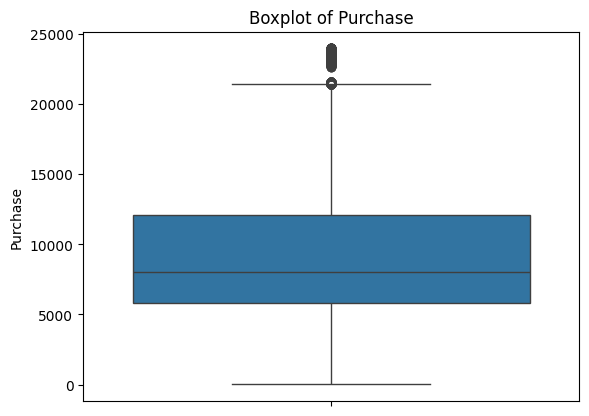

In [13]:
plt.figure()
sns.boxplot(y=df['Purchase'])
plt.title('Boxplot of Purchase')
plt.show

In [14]:
Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Purchase'] < lower) | (df['Purchase'] > upper)]

print(f"Purchase: {len(outliers)} outliers")

Purchase: 2677 outliers


In [15]:
df['Purchase'] = np.clip(df['Purchase'],df['Purchase'].quantile(0.05) , df['Purchase'].quantile(0.95))

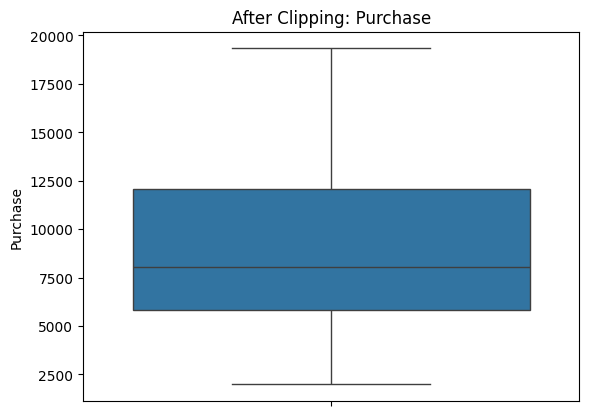

In [16]:
plt.figure()
sns.boxplot(y=df['Purchase'])
plt.title('After Clipping: Purchase')
plt.show()

In [17]:
Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Purchase'] < lower) | (df['Purchase'] > upper)]

print(f"Purchase: {len(outliers)} outliers")

Purchase: 0 outliers


### Univariate-Bivariate Analysis

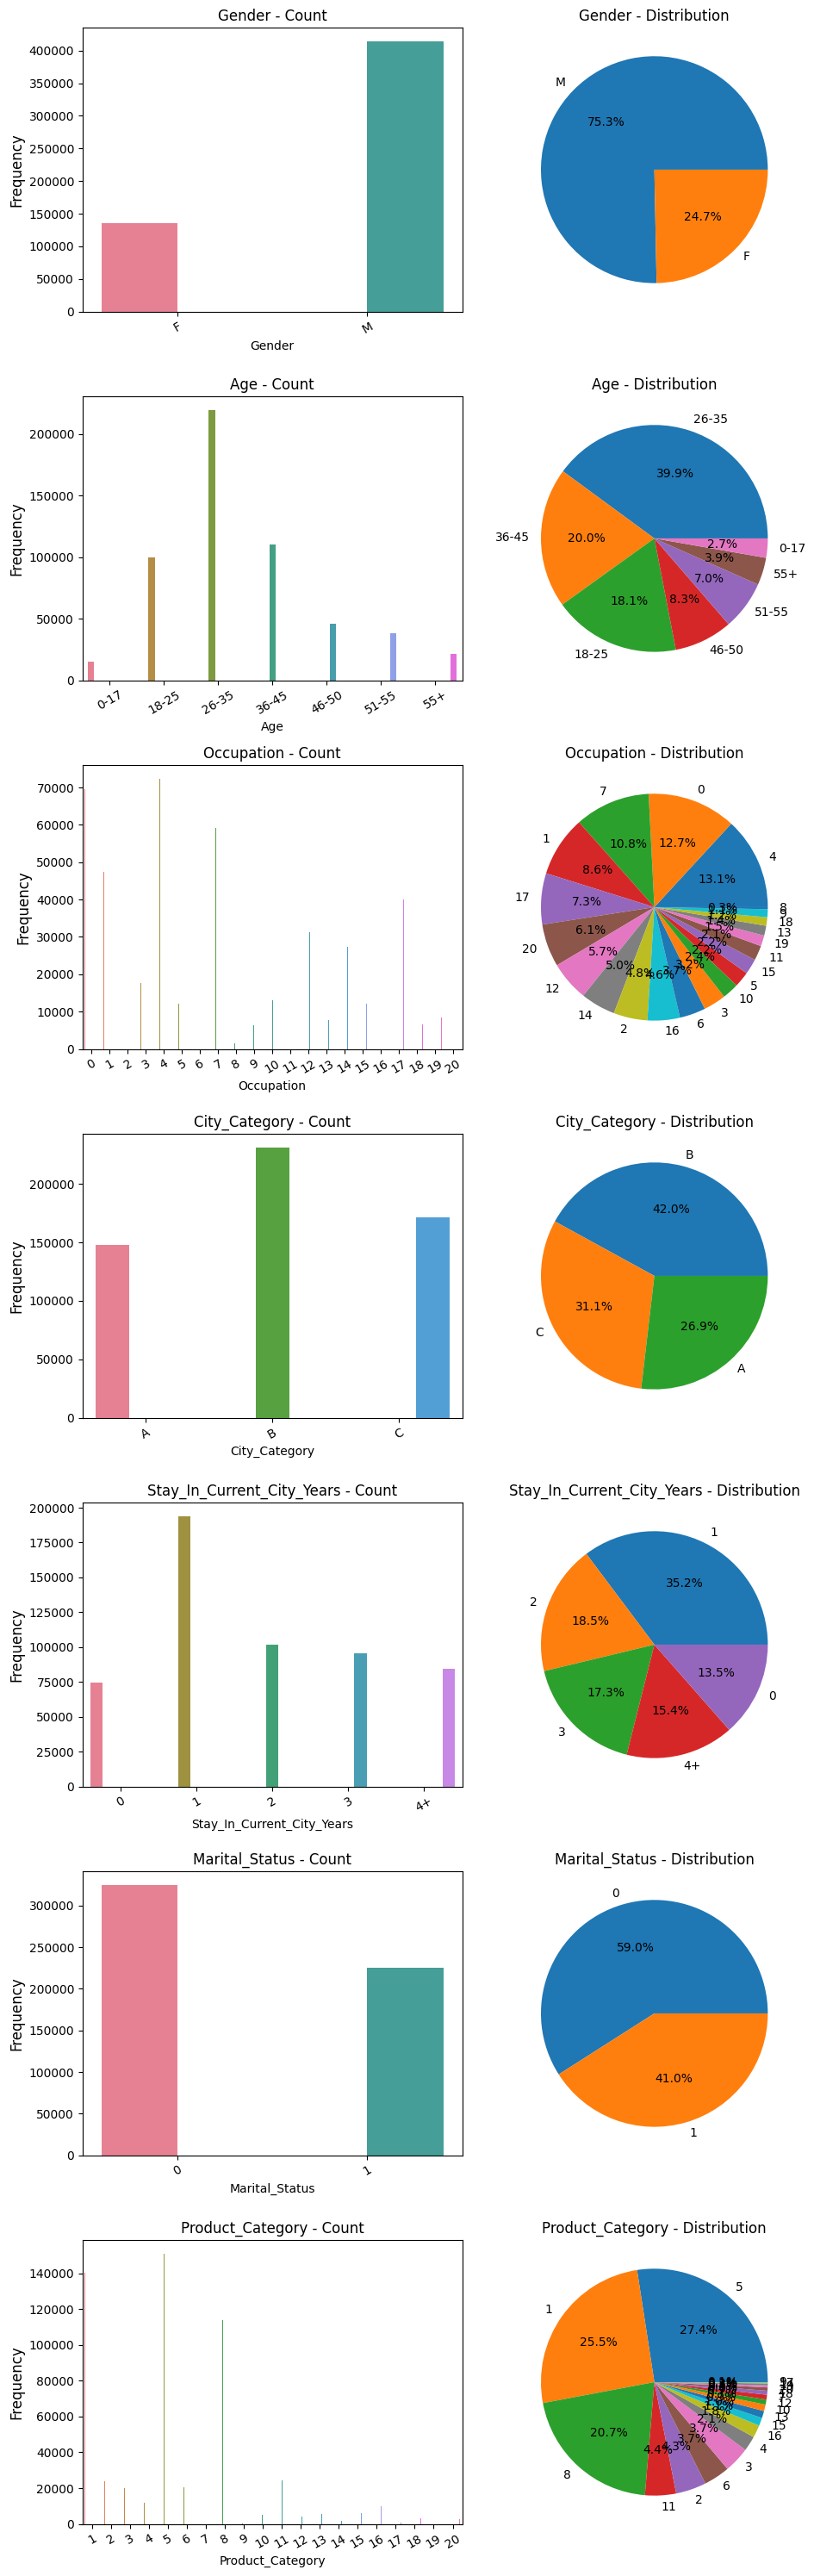

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplot grid (7 rows, 2 columns)
fig, axes = plt.subplots(7, 2, figsize=(10, 30))

columns = [
     'Gender',
     'Age',
    'Occupation', 
    'City_Category',
    'Stay_In_Current_City_Years', 
    'Marital_Status', 
    'Product_Category'

]

for i, col in enumerate(columns):
    
    # BAR PLOT
    sns.countplot(
        x=col,
        data=df,
        ax=axes[i][0],
        hue = col,
        palette="husl",
        legend = False
    )
    axes[i][0].set_title(f"{col} - Count", fontsize=12)
    axes[i][0].set_ylabel("Frequency", fontsize=12)
    axes[i][0].tick_params(axis='x', rotation=30)
    
    # PIE CHART
    df[col].value_counts().plot.pie(
        autopct="%.1f%%",
        ax=axes[i][1],
        textprops={"fontsize": 10}
    )
    axes[i][1].set_title(f"{col} - Distribution", fontsize=12)
    axes[i][1].set_ylabel("")

plt.tight_layout()
plt.show()

# Key Insights

1. Product categories **5, 1, and 8** are the most frequently purchased categories, with Category 5 alone contributing approximately **27.4%** of total purchases.

2. Approximately **75.3%** of customers purchasing products are male, indicating significantly higher participation from male customers compared to females.

3. Around **59%** of customers are unmarried, while **41%** are married, showing higher shopping frequency among unmarried customers.

4. Customers aged **26–35 years** form the largest customer segment, contributing nearly **40%** of the total customer base.

5. **City Category B** contributes the highest customer share at approximately **42%**, followed by Categories C and A.

6. Customers who have stayed in the current city for **1 year** account for the highest proportion of shoppers (**35.2%**), suggesting stronger activity among relatively newer residents.

7. Occupation categories **0, 4, and 7** represent some of the most active customer groups in the dataset.

8. Product categories **1, 6, 7, 10, 14, and 16** show comparatively higher purchase amounts based on median purchase distribution.

9. Product categories such as **4, 11, 12, 13, 18, 19, and 20** have relatively lower purchase values compared to other categories.

10. The dataset indicates that young to middle-aged adults, particularly males from City Category B, form the dominant consumer segment.

### Bivariate Analysis

#####   Age vs Purchase

C:\Users\Aditya Deshmukh\AppData\Local\Temp\ipykernel_6020\1979253957.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Aditya Deshmukh\AppData\Local\Temp\ipykernel_6020\1979253957.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


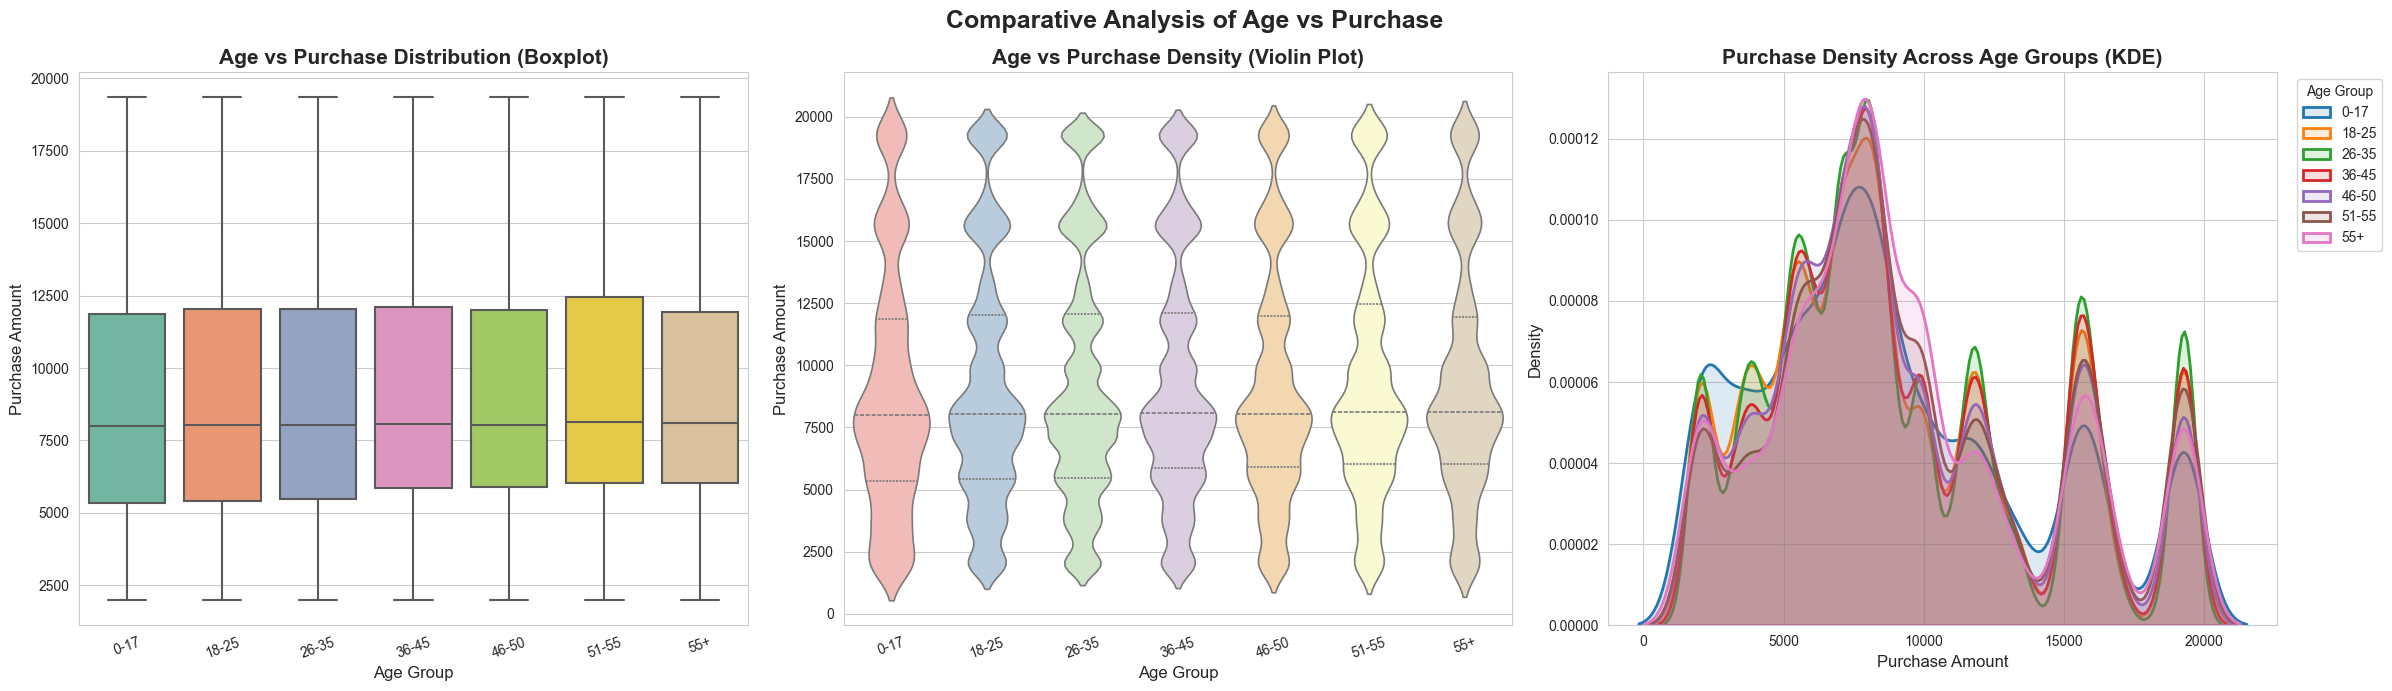

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (24, 7)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Boxplot
sns.boxplot(
    x='Age',
    y='Purchase',
    data=df,
    palette='Set2',
    linewidth=1.5,
    showfliers=False,
    ax=axes[0]
)

axes[0].set_title(
    'Age vs Purchase Distribution (Boxplot)',
    fontsize=15,
    fontweight='bold'
)

axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Purchase Amount', fontsize=12)
axes[0].tick_params(axis='x', rotation=20)

# Violin Plot
sns.violinplot(
    x='Age',
    y='Purchase',
    data=df,
    palette='Pastel1',
    inner='quartile',
    linewidth=1.2,
    ax=axes[1]
)

axes[1].set_title(
    'Age vs Purchase Density (Violin Plot)',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('Purchase Amount', fontsize=12)
axes[1].tick_params(axis='x', rotation=20)

# Kde plot
age_groups = sorted(df['Age'].unique())

for age_group in age_groups:
    sns.kdeplot(
        data=df[df['Age'] == age_group],
        x='Purchase',
        fill=True,
        alpha=0.15,
        linewidth=2,
        label=age_group,
        ax=axes[2]
    )

axes[2].set_title(
    'Purchase Density Across Age Groups (KDE)',
    fontsize=15,
    fontweight='bold'
)

axes[2].set_xlabel('Purchase Amount', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)

axes[2].legend(
    title='Age Group',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)


plt.suptitle(
    'Comparative Analysis of Age vs Purchase',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [20]:
groups_age = [
    df[df['Age'] == age]['Purchase']
    for age in df['Age'].unique()
]


In [21]:
# we will use anova to check relation of age as categorical vs purchase

# we check if age fullfills the conditions for Anova

# 1. Check if the Data is Normally Distributed

# H0: Normally Distributed
# Ha: Not Normally Distributed

In [22]:
from scipy.stats import shapiro

stat, p_value = shapiro(df['Purchase'])

print("Shapiro Statistic:", stat)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Data is NOT normally distributed")
else:
    print("Data is normally distributed")


Shapiro Statistic: 0.9364252285461521
p-value: 1.4953071428930613e-131
Data is NOT normally distributed


C:\Users\Aditya Deshmukh\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 550068.
  res = hypotest_fun_out(*samples, **kwds)


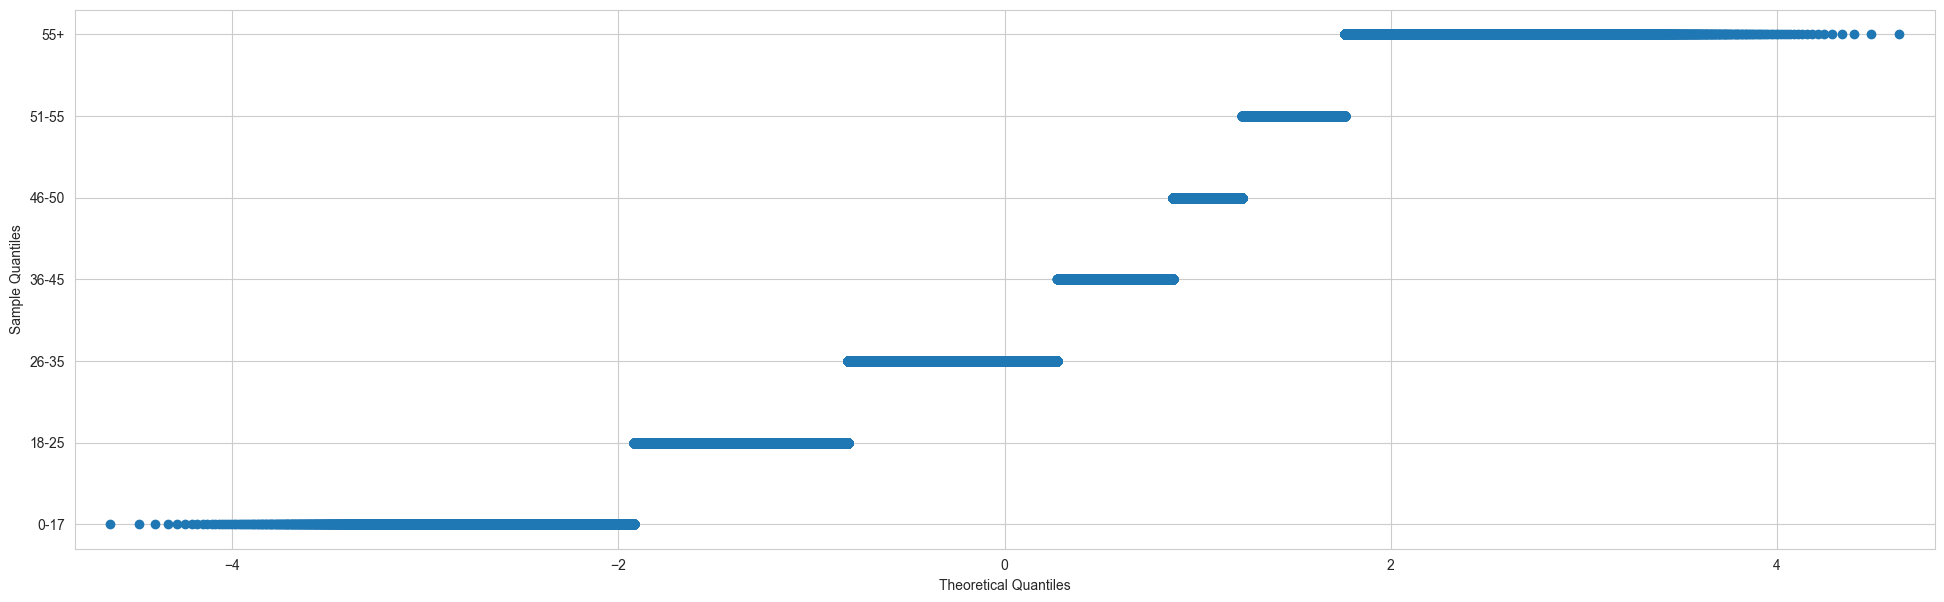

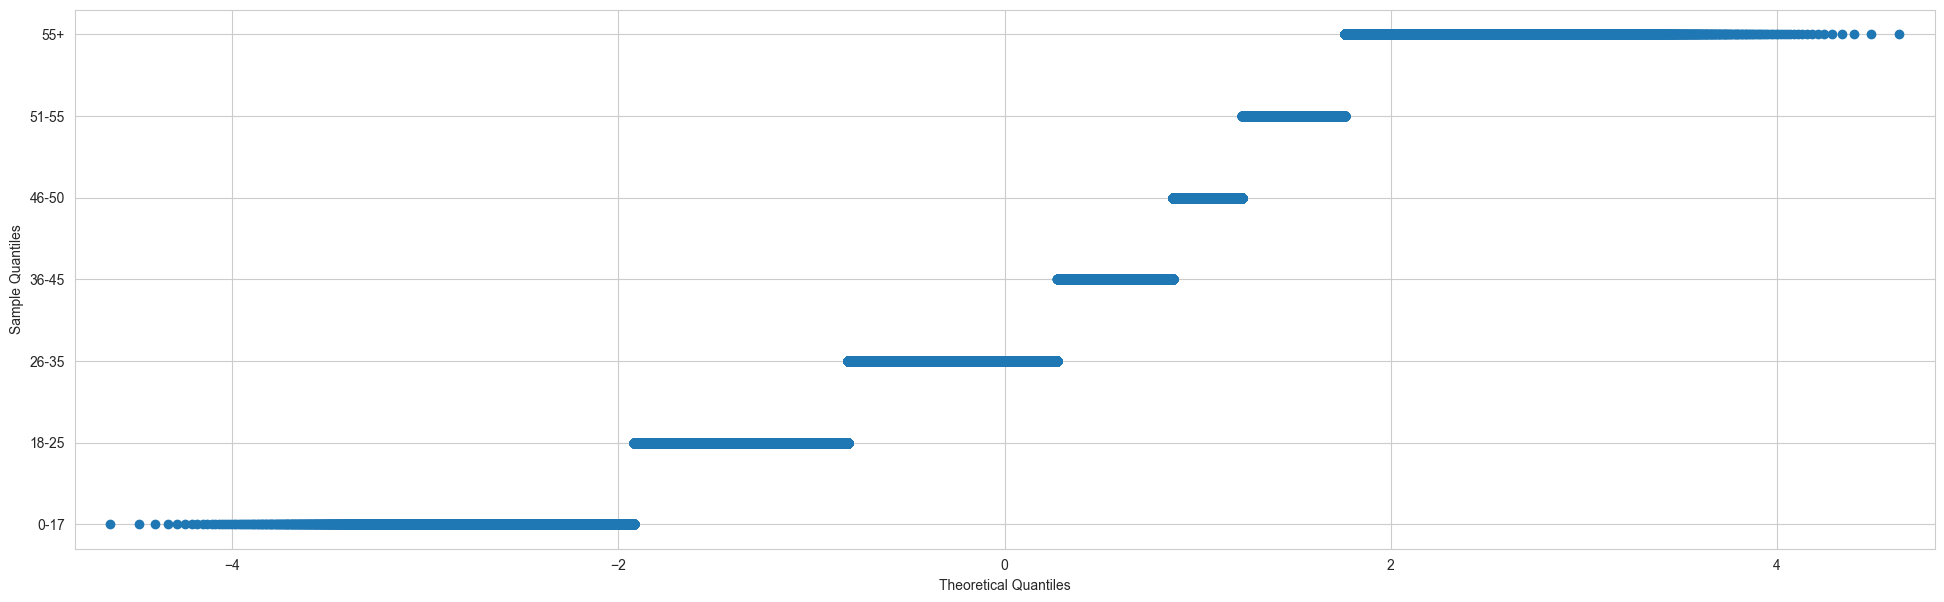

In [23]:
from statsmodels.graphics.gofplots import qqplot

qqplot(data= df["Age"])

In [24]:
from scipy.stats import levene,kruskal

In [25]:
stat, p_value = levene(*groups_age)

print("Levene Statistic:", stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Variances are NOT equal (assumption violated) , Reject H0")
else:
    print("Variances are equal (assumption satisfied) , Fail to Reject H0 ")

Levene Statistic: 15.88253276087288
p-value: 2.408983118206475e-18
Variances are NOT equal (assumption violated) , Reject H0


In [26]:
# Krushkal- Wallis Test as Normality does not hold

# H0: Purchase distributions differ across age groups
# Ha: No significant difference in purchase distributions across age groups

In [27]:
from scipy.stats import kruskal

stat, p_value = kruskal(*groups_age)

print("Kruskal Statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Purchase distributions differ across age groups")
else:
    print("Fail to reject H0 → No significant difference in purchase distributions across age groups")

Kruskal Statistic: 316.4269448321753
p-value: 2.4643859961952855e-65
Reject H0 → Purchase distributions differ across age groups


Although the statistical test indicates significant differences,
visualizations show substantial overlap between age groups,
suggesting that the practical impact of age on purchase amount may be limited.

- Customers belonging to the **26–35** age group form the largest customer segment in the dataset.
- Visual analysis using boxplots, violin plots, and KDE plots shows that purchase distributions across age groups are highly overlapping and relatively similar.
- Although the Kruskal-Wallis test indicates statistically significant differences in purchase distributions between age groups, the actual variation in purchase behavior appears relatively small in practical terms.
- Median purchase values and overall purchase spread remain fairly consistent across most age categories.
- This suggests that while age has a statistically detectable relationship with purchase amount, it may not be one of the strongest factors influencing customer spending behavior.
- Other variables such as product category, occupation, or city category may have a comparatively greater impact on purchase amount.

In [28]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='str')

##### Gender vs Purchase

In [29]:
bins = [0, 5000, 10000, 15000, 25000]

labels = [
    'Low Spend',
    'Medium Spend',
    'High Spend',
    'Premium Spend'
]

df['Purchase_Bins'] = pd.cut(
    df['Purchase'],
    bins=bins,
    labels=labels
)

In [30]:
grp = df.groupby(['Purchase_Bins','Gender']).size().reset_index(name='counts')
grp

,Purchase_Bins,Gender,counts
0,Low Spend,F,24239
1,Low Spend,M,70684
2,Medium Spend,F,72629
3,Medium Spend,M,193066
4,High Spend,F,17512
5,High Spend,M,61415
6,Premium Spend,F,21429
7,Premium Spend,M,89094


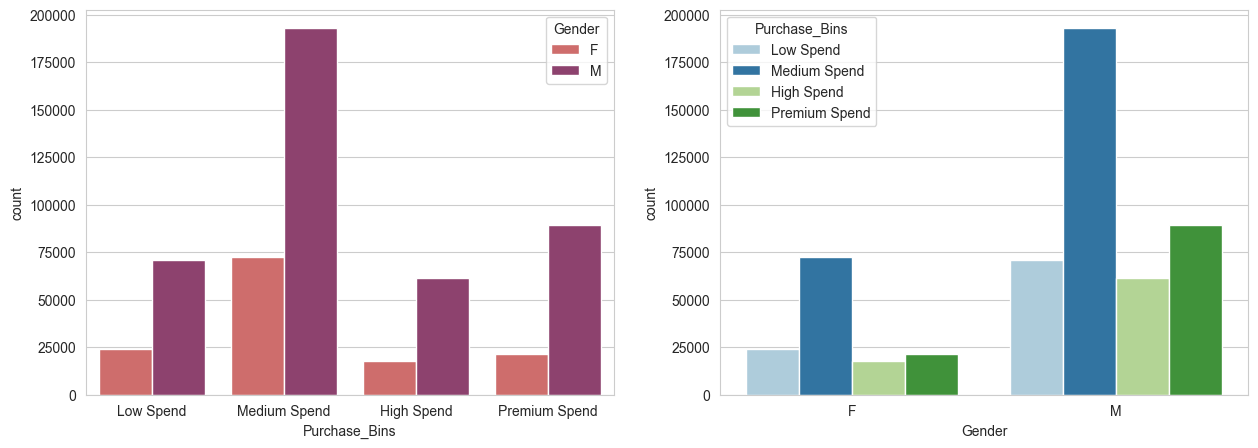

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15,5)) 
sns.countplot (data = df, x='Purchase_Bins', hue='Gender', palette="flare", ax=axes[0]) 
sns.countplot(data = df, x='Gender', hue='Purchase_Bins', palette="Paired", ax=axes[1])

plt.show()

- The data itself is male dominaated so we create a normalised table to actually check the percentages as raw values will always show 

In [32]:



normalized_table_gender = pd.crosstab(
    df['Gender'],
    df['Purchase_Bins'],
    normalize='index'
) * 100

normalized_table_gender

Purchase_Bins,Low Spend,Medium Spend,High Spend,Premium Spend
Gender,,,,
F,17.847860,53.478783,12.894580,15.778778
M,17.062755,46.605143,14.825266,21.506835


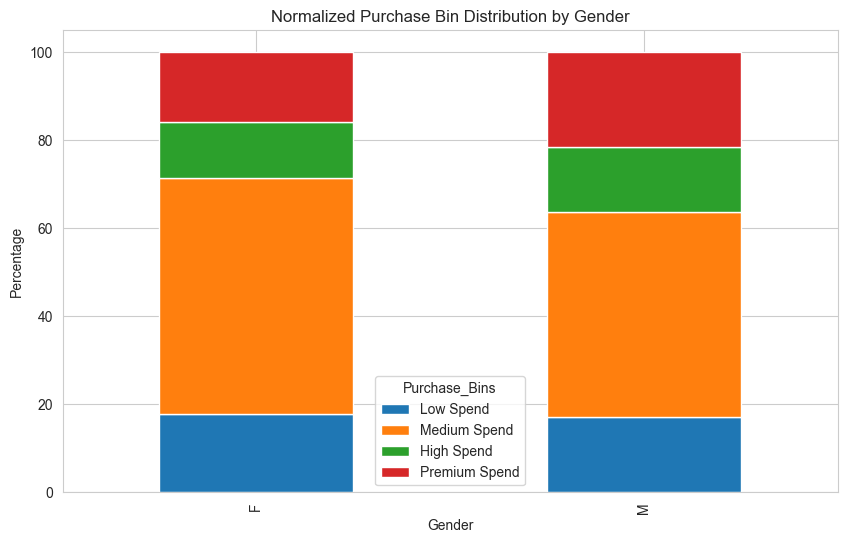

In [33]:
normalized_table_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Normalized Purchase Bin Distribution by Gender')
plt.ylabel('Percentage')
plt.legend(title='Purchase_Bins')
plt.show()

In [34]:
from scipy.stats import chi2_contingency


G_P_matrix = pd.crosstab( df['Gender'],
    df['Purchase_Bins'])


test_statistic, p_value, dof, expected_values = chi2_contingency(G_P_matrix)


print("Test statistic:", test_statistic)
print("p-value:", p_value)
print("dof", dof)
print("expected_values",expected_values)

alpha = 0.05

if(p_value < alpha):
  print("Reject H0 (Null Hypothesis),i.e.Gender and Purchase_Bins are dependent .")
else:
  print("Fail to Reject H0 (Null Hypothesis),i.e. Gender and Purchase_Bins are independent")


Test statistic: 2972.853432591687
p-value: 0.0
dof 3
expected_values [[ 23436.00737909  65598.74825476  19486.67608914  27287.56827701]
 [ 71486.99262091 200096.25174524  59440.32391086  83235.43172299]]
Reject H0 (Null Hypothesis),i.e.Gender and Purchase_Bins are dependent .


###### Gender vs Purchase Bin Insights

- Female customers are more concentrated in the **Medium Spend** category, with approximately **53.48%** of female customers falling into this segment.

- Male customers have a higher proportion in the **Premium Spend** category (**21.51%**) compared to female customers (**15.78%**).

- Male customers also show a slightly higher representation in the **High Spend** category (**14.83%**) than female customers (**12.89%**).

- The proportion of customers in the **Low Spend** category is relatively similar across genders, with females at **17.85%** and males at **17.06%**.

- Overall, male customers appear more likely to fall into higher spending segments compared to female customers.

- Female customers are more concentrated in moderate spending ranges, whereas male customers show greater representation among high-value and premium purchasers.

In [35]:
# Checking CLT and CI

In [36]:
male_purchase = df[df['Gender'] == 'M']['Purchase']
female_purchase = df[df['Gender'] == 'F']['Purchase']

In [37]:
sample_means_male = []

for i in range(1000):
    sample = male_purchase.sample(500, replace=True)
    sample_means_male.append(sample.mean())
    

<Axes: ylabel='Count'>

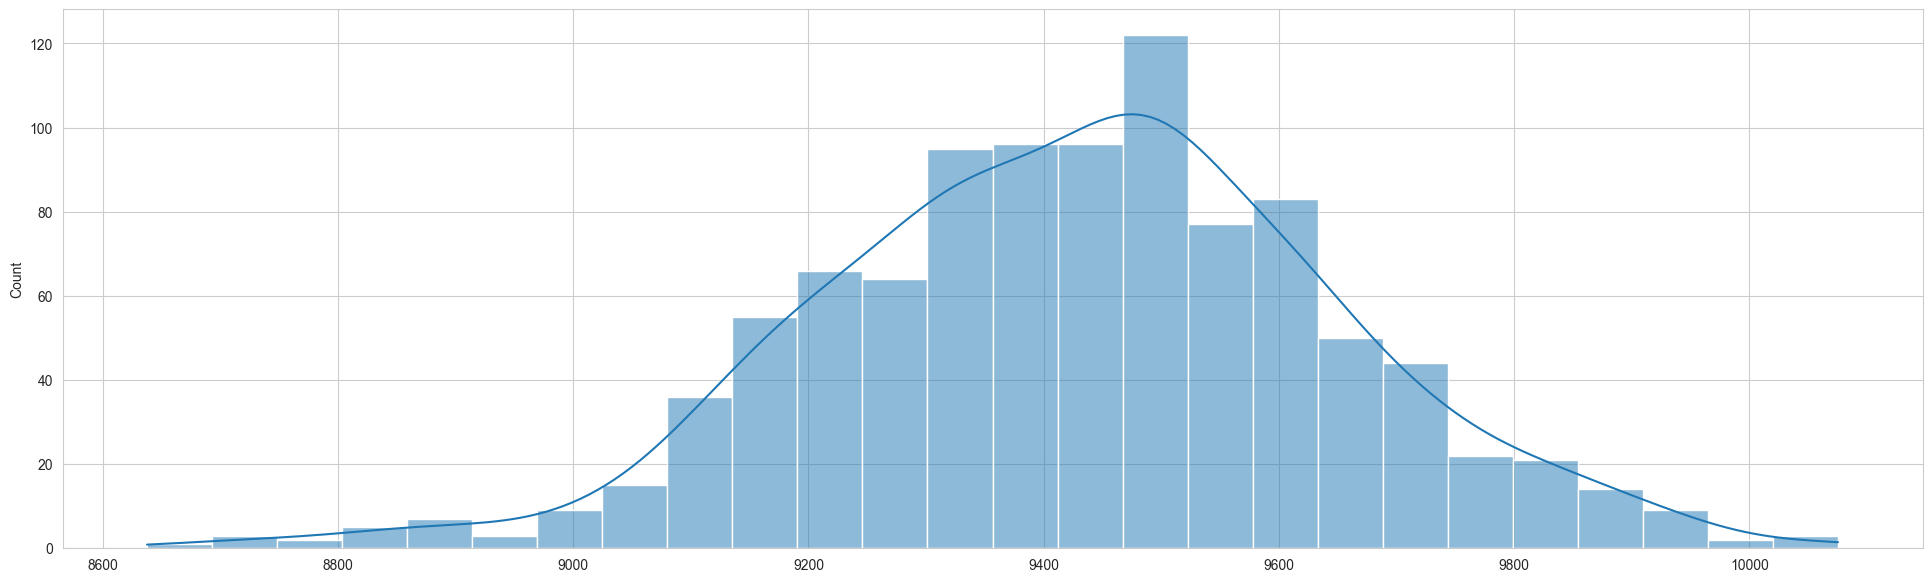

In [38]:
sns.histplot(x=sample_means_male, kde=True)

In [39]:
import scipy.stats as stats

mean = male_purchase.mean()
std = male_purchase.std()
n = len(male_purchase)

confidence = 0.95

male_ci = stats.norm.interval(
    confidence,
    loc=mean,
    scale=std / np.sqrt(n) # Standard Error
)

male_ci

(np.float64(9412.240611016148), np.float64(9442.241382133065))

In [40]:
sample_means_female = []

for i in range(1000):
    sample = female_purchase.sample(500,replace=True)
    sample_means_female.append(sample)


<Axes: ylabel='Count'>

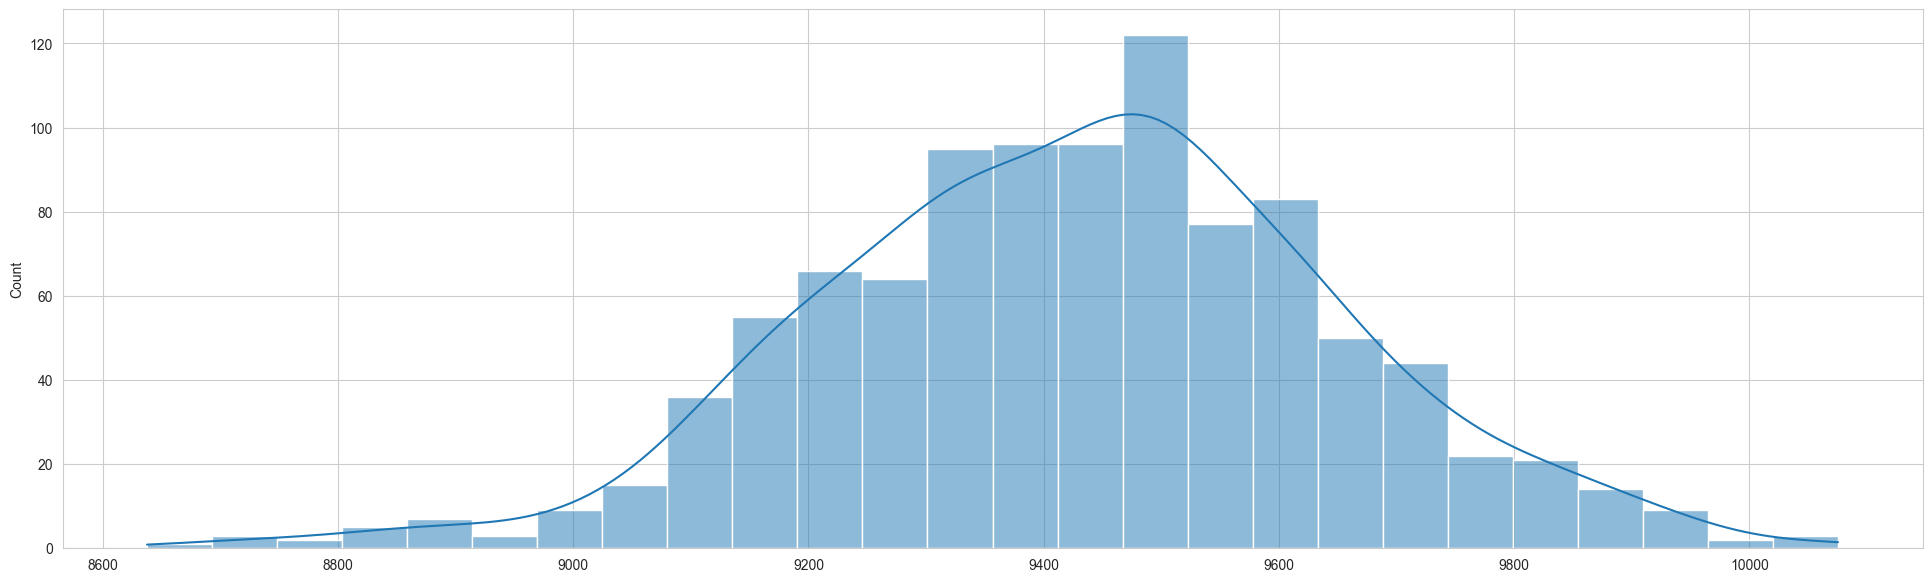

In [41]:
sns.histplot(x=sample_means_male,kde=True)

In [42]:
mean_f = female_purchase.mean()
std_f = female_purchase.std()

n = len(female_purchase)

confidence = 0.95
    
female_ci = stats.norm.interval(
    confidence,
    loc=mean_f,
    scale=std_f / np.sqrt(n)
)

female_ci

(np.float64(8712.091504525708), np.float64(8760.989027692334))

###### Confidence Interval Insights

- The 95% confidence interval for average male purchase amount lies between approximately **9412 and 9442**.
- The 95% confidence interval for average female purchase amount lies between approximately **8712 and 8761**.
- Since the confidence intervals do not overlap, male customers appear to have significantly higher average purchase amounts compared to female customers.
- The intervals are relatively narrow, indicating stable estimates due to the large sample size.

##### Marital_status vs Purchase

In [43]:
df.groupby(['Purchase_Bins','Marital_Status']).size().reset_index(name='counts')

,Purchase_Bins,Marital_Status,counts
0,Low Spend,0,56459
1,Low Spend,1,38464
2,Medium Spend,0,156046
3,Medium Spend,1,109649
4,High Spend,0,46596
5,High Spend,1,32331
6,Premium Spend,0,65630
7,Premium Spend,1,44893


<Axes: xlabel='Marital_Status', ylabel='count'>

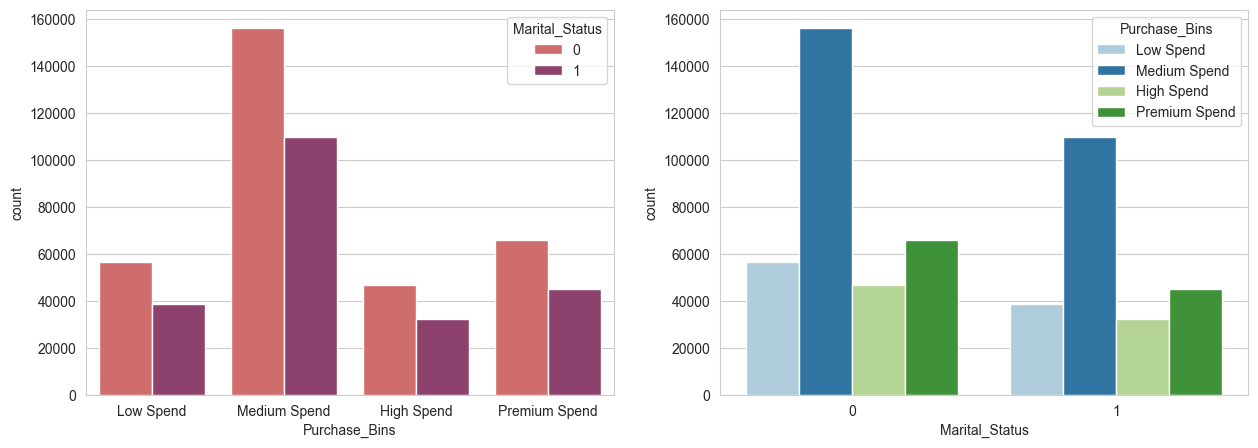

In [44]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df, x='Purchase_Bins', hue= 'Marital_Status', palette= 'flare', ax= axes[0])
sns.countplot(data=df, x= 'Marital_Status', hue= 'Purchase_Bins', palette= 'Paired', ax= axes[1])



- Purchase segment distributions across marital status categories appear relatively similar.
- Both married and unmarried customers are concentrated primarily in the Medium Spend category.
- No strong separation in spending behavior is visually observed between the two marital status groups.
- This suggests that marital status may not be a major factor influencing customer purchase behavior.

In [45]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase', 'Purchase_Bins'],
      dtype='str')

##### occupation vs Purchase

<Axes: xlabel='Marital_Status', ylabel='count'>

C:\Users\Aditya Deshmukh\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\Aditya Deshmukh\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


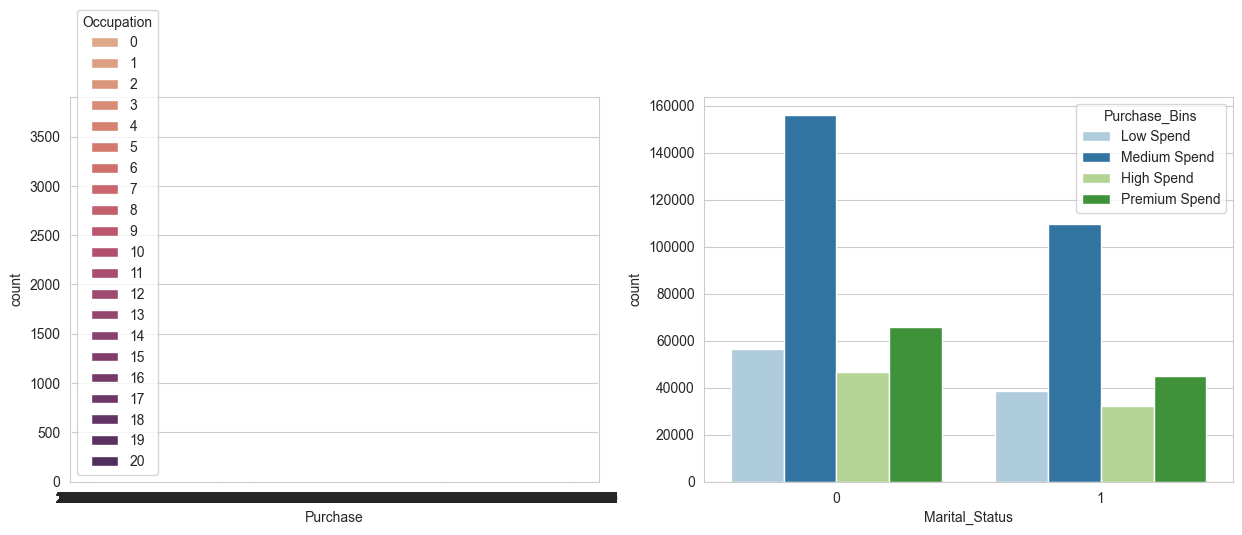

In [46]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df, x='Purchase', hue= 'Occupation', palette= 'flare', ax= axes[0])
sns.countplot(data=df, x= 'Marital_Status', hue= 'Purchase_Bins', palette= 'Paired', ax= axes[1])


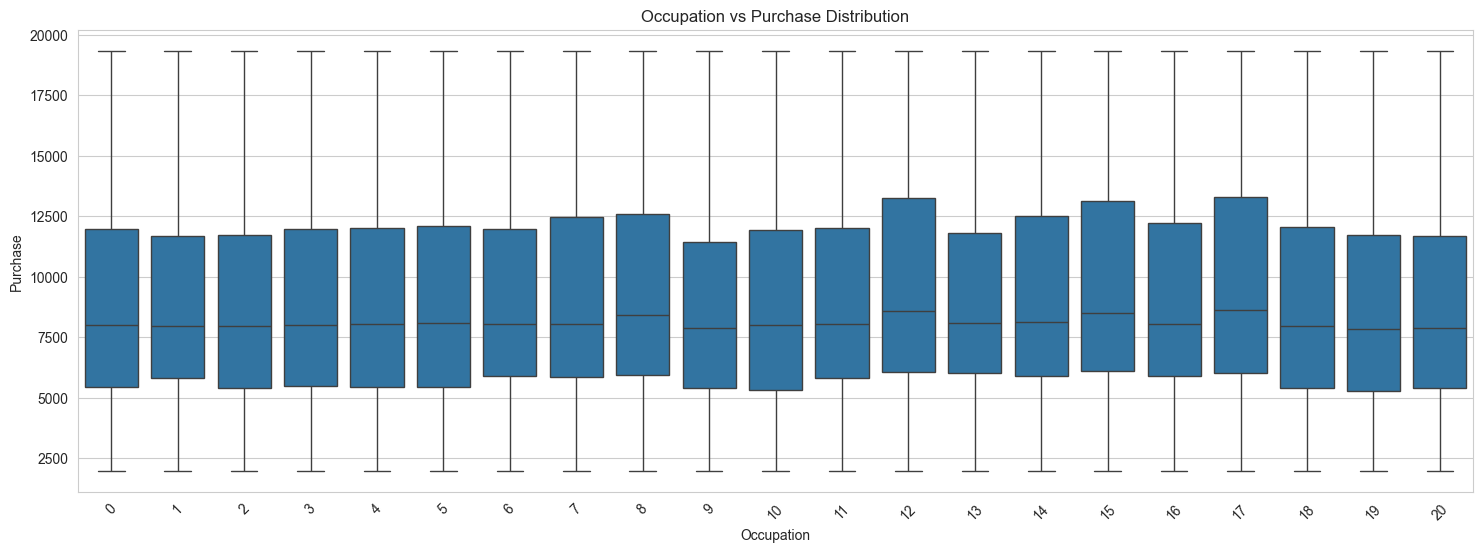

In [47]:
plt.figure(figsize=(18,6))

sns.boxplot(
    x='Occupation',
    y='Purchase',
    data=df,
    showfliers=False
)

plt.title('Occupation vs Purchase Distribution')
plt.xticks(rotation=45)
plt.show()

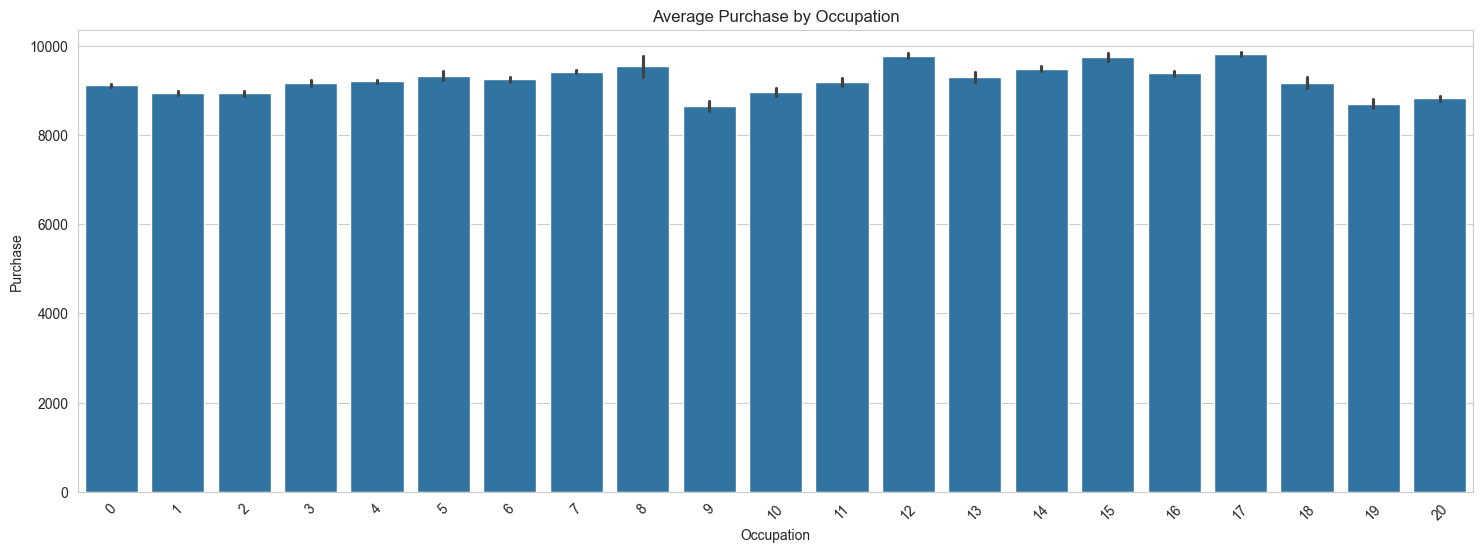

In [48]:
plt.figure(figsize=(18,6))

sns.barplot(
    x='Occupation',
    y='Purchase',
    data=df
)

plt.title('Average Purchase by Occupation')
plt.xticks(rotation=45)
plt.show()

In [49]:
occupation_mean = df.groupby('Occupation')['Purchase'].mean()

occupation_mean.sort_values(ascending=False)

Occupation
17    9816.474340
12    9782.292152
15    9757.346650
8     9537.546572
14    9488.400161
7     9420.474490
16    9386.824642
5     9328.595631
13    9300.149198
6     9246.361238
4     9208.712203
11    9197.213706
3     9170.350368
18    9169.565690
0     9118.530544
10    8972.975251
1     8948.985873
2     8939.499511
20    8821.253143
19    8705.822598
9     8655.518677
Name: Purchase, dtype: float64

In [50]:

groups_occ = [df[df['Occupation'] == occ ]['Purchase'] for occ in df['Occupation'].unique()]


stat, p_value = kruskal(*groups_occ)

print("Kruskal Statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Purchase distributions differ across occupations")
else:
    print("Fail to reject H0 → No significant difference in purchase distributions across occupations")

Kruskal Statistic: 1947.887869459302
p-value: 0.0
Reject H0 → Purchase distributions differ across occupations



- The Kruskal-Wallis test indicates statistically significant differences in purchase distributions across occupation groups.
- However, boxplot analysis shows substantial overlap between occupation-wise purchase distributions.
- Although certain occupations exhibit relatively higher average purchase amounts, the practical differences appear moderate rather than extreme.
- This suggests that occupation contributes to customer purchasing behavior, but may not independently act as a dominant predictor of purchase amount.

In [51]:
df.columns


Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase', 'Purchase_Bins'],
      dtype='str')

<Axes: xlabel='City_Category', ylabel='count'>

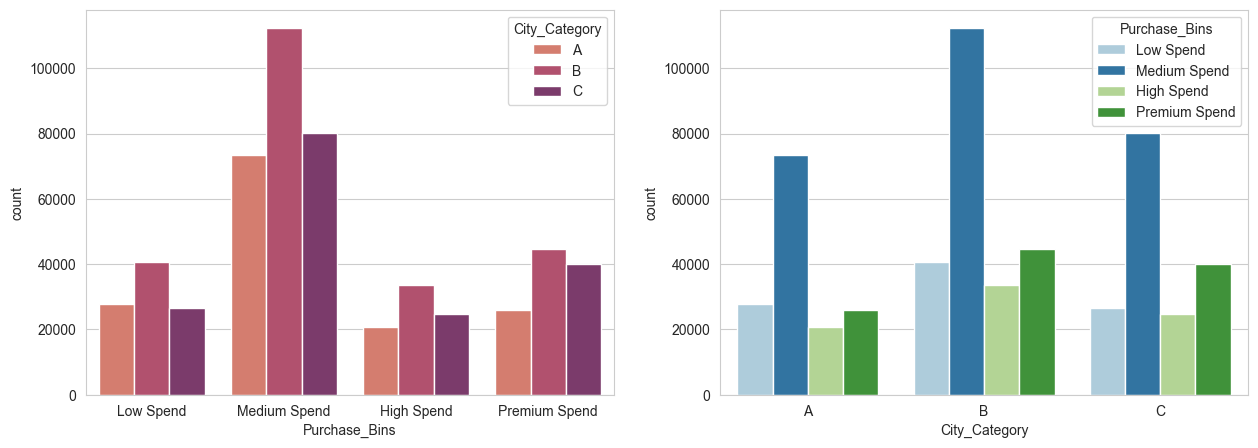

In [52]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df, x='Purchase_Bins', hue= 'City_Category', palette= 'flare', ax= axes[0])
sns.countplot(data=df, x= 'City_Category', hue= 'Purchase_Bins', palette= 'Paired', ax= axes[1])



In [53]:
city_norm = pd.crosstab(
    df['City_Category'],
    df['Purchase_Bins'],
    normalize='index'
) * 100

city_norm

Purchase_Bins,Low Spend,Medium Spend,High Spend,Premium Spend
City_Category,,,,
A,18.835635,49.608719,14.008259,17.547387
B,17.582071,48.612944,14.484390,19.320595
C,15.454360,46.755075,14.458887,23.331678




- Customers across all city categories are predominantly concentrated in the Medium Spend segment.
- City Category C exhibits the highest proportion of Premium Spend customers (~23.33%), indicating a relatively stronger concentration of high-value customers.
- City Category A contains the highest proportion of Low Spend customers (~18.84%), suggesting comparatively lower spending behavior.
- City Categories B and C show relatively stronger representation in higher spending segments compared to City Category A.
- Overall, city category appears to have a moderate influence on customer spending behavior and may provide useful information for customer targeting and segmentation strategies.

##### Stay_In_Current_City_Years vs Purchhase

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

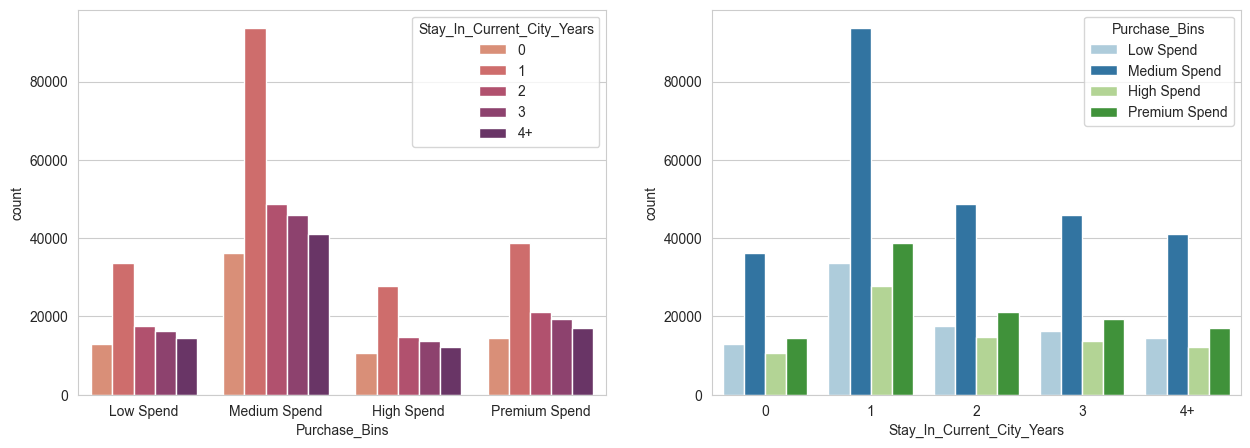

In [54]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df, x='Purchase_Bins', hue= 'Stay_In_Current_City_Years', palette= 'flare', ax= axes[0])
sns.countplot(data=df, x= 'Stay_In_Current_City_Years', hue= 'Purchase_Bins', palette= 'Paired', ax= axes[1])



In [55]:
city_norm = pd.crosstab(
    df['Stay_In_Current_City_Years'],
    df['Purchase_Bins'],
    normalize='index'
) * 100

city_norm

Purchase_Bins,Low Spend,Medium Spend,High Spend,Premium Spend
Stay_In_Current_City_Years,,,,
0,17.526009,48.715019,14.378075,19.380897
1,17.359832,48.339963,14.306499,19.993706
2,17.125238,47.852472,14.400322,20.621968
3,17.118119,48.222700,14.363226,20.295954
4+,17.097467,48.483346,14.340344,20.078842


- Purchase segment distributions remain highly consistent across all customer groups based on years spent in the current city.
- Overall, the number of years a customer has stayed in the current city does not appear to strongly influence customer spending behavior.

##### Multivariate-Analysis

###### Gender x Product Category vs Purchase

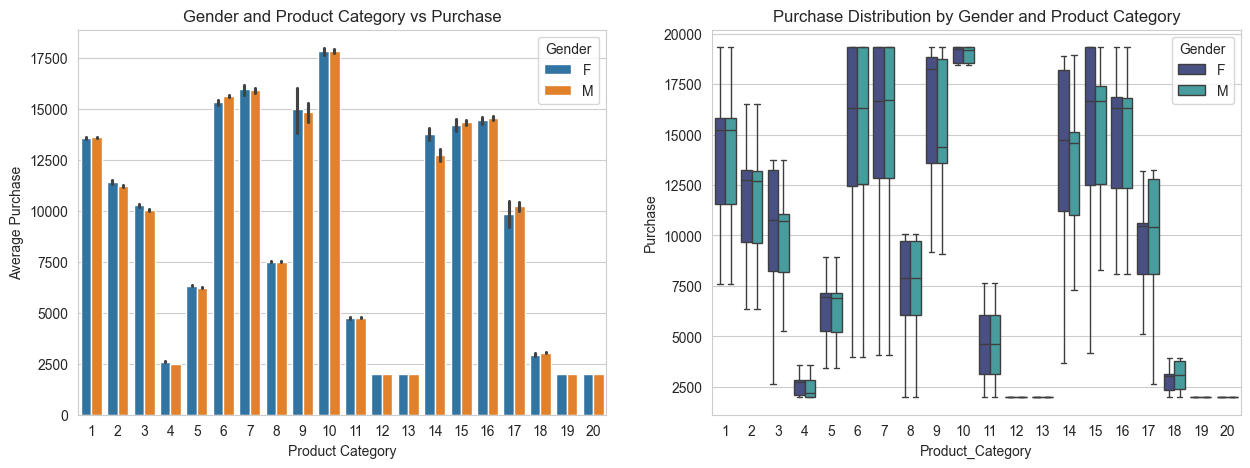

In [59]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

# Barplot

sns.barplot(
    x='Product_Category',
    y='Purchase',
    hue='Gender',
    data=df,
    ax= axes[0]
)

axes[0].set_title('Gender and Product Category vs Purchase')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Average Purchase')

# Boxplot

sns.boxplot(
    x='Product_Category',
    y='Purchase',
    hue='Gender',
    palette = 'mako',
    data=df,
    showfliers=False,
    ax = axes[1]
)

axes[1].set_title('Purchase Distribution by Gender and Product Category')


plt.show()

- Product category appears to have a stronger influence on purchase amount compared to gender alone.
- Purchase distributions vary significantly across product categories, while male and female purchase patterns within many categories remain relatively similar.
- Certain product categories exhibit noticeable gender-based differences in average purchase amount, suggesting possible differences in product preferences across genders.
- Product categories `9`, `10`, `15`, and `16` consistently show the highest purchase amounts across both male and female customers, indicating the presence of high-value product segments.
- Categories such as `12`, `13`, `19`, and `20` display minimal variation in purchase values, suggesting relatively fixed or standardized pricing behavior.
- Overall, customer spending behavior appears to be driven more strongly by product category than by gender individually.

###### Gender × City_Category vs Purchase

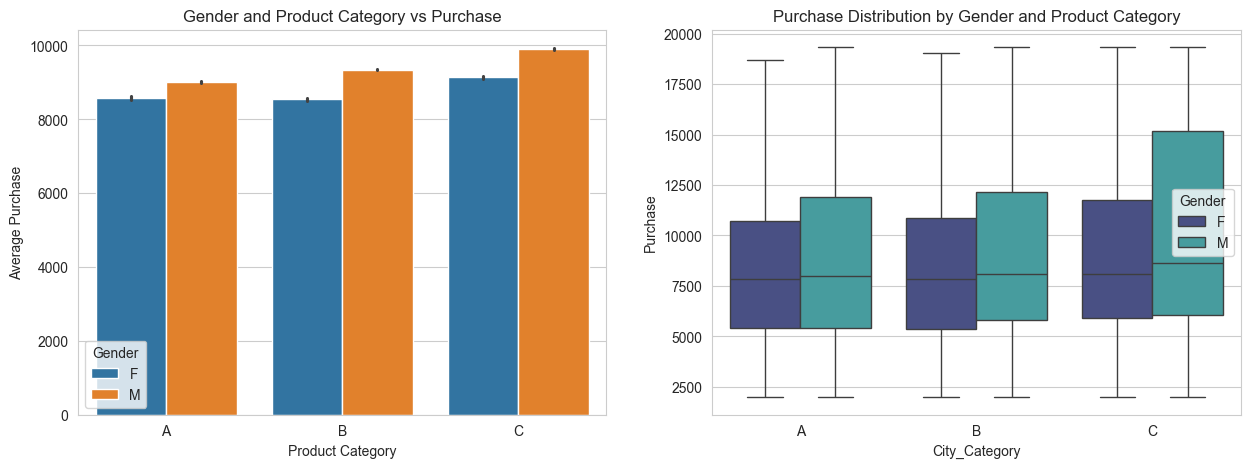

In [60]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

# Barplot

sns.barplot(
    x='City_Category',
    y='Purchase',
    hue='Gender',
    data=df,
    ax= axes[0]
)

axes[0].set_title('Gender and City Category vs Purchase')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Average Purchase')

# Boxplot

sns.boxplot(
    x='City_Category',
    y='Purchase',
    hue='Gender',
    palette = 'mako',
    data=df,
    showfliers=False,
    ax = axes[1]
)

axes[1].set_title('Purchase Distribution by Gender and city Category')


plt.show()

In [ ]:

corr = df[['Age', 'Income', 'Usage', 'Fitness', 'Miles']].corr()
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


- Male customers consistently exhibit higher average purchase amounts across all city categories.
- City Category C demonstrates the highest average purchase behavior for both male and female customers.
- The spending gap between male and female customers appears strongest within City Category C.
- Despite differences in average spending, purchase distributions overlap substantially across groups, indicating moderate rather than extreme behavioral separation.
- City category and gender together contribute to customer purchasing behavior and may be useful for customer segmentation and targeted marketing strategies.

In [65]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase', 'Purchase_Bins'],
      dtype='str')

##### CENTRAL LIMIT THEOREM & CONFIDENCE INTERVAL ANALYSIS

In [71]:
sns.set_style("whitegrid")

In [74]:
male_purchase.shape

(414259,)

In [75]:
female_purchase.shape

(135809,)

- we can clearly see that the data is male dominant

In [135]:

# Func for generating sample means

def generate_sample_means(data, sample_size, n_iterations=1000):

    return [
        data.sample(sample_size, replace=True).mean()
        for _ in range(n_iterations)
    ]



In [147]:

# Fuunction for CLT

def clt_analysis(
    group1_data,
    group2_data,
    group1_name='Group 1',
    group2_name='Group 2',
    sample_sizes=[300, 3000, 30000],
    confidence=0.95,
    n_iterations=1000,
    plot=True
):

    results = []

    print("\n" + "*"*75)
    print(f"CLT & CONFIDENCE INTERVAL ANALYSIS")
    print(f"{group1_name} vs {group2_name}")
    print("*"*75)

# Full Data CI

    group1_mean = group1_data.mean()

    group1_std = group1_data.std()

    group1_n = len(group1_data)

    group1_ci = norm.interval(
        confidence,
        loc=group1_mean,
        scale=group1_std / np.sqrt(group1_n)
    )


    group2_mean = group2_data.mean()

    group2_std = group2_data.std()

    group2_n = len(group2_data)

    group2_ci = norm.interval(
        confidence,
        loc=group2_mean,
        scale=group2_std / np.sqrt(group2_n)
    )


    print("\nFULL DATASET CONFIDENCE INTERVALS")
    print("-"*75)

    print(f"\n{group1_name} Mean : {group1_mean:.2f}")
    print(f"{group1_name} CI   : {group1_ci}")

    print(f"\n{group2_name} Mean : {group2_mean:.2f}")
    print(f"{group2_name} CI   : {group2_ci}")

# Check Overlap

    print("\nOVERLAP INTERPRETATION")
    print("-"*75)

    if group1_ci[0] > group2_ci[1] or group2_ci[0] > group1_ci[1]:

        print("\nConfidence Intervals DO NOT overlap")

        print(f"""\nInterpretation:\nAverage spending differs significantly between \n{group1_name} and {group2_name}. """)

    else:

        print("\nConfidence Intervals overlap")

        print(f"""\nInterpretation:\nAverage spending behavior may be similar between\n{group1_name} and {group2_name}.""")

# CLT across sammples
    
    for size in sample_sizes:

        # 1. generate sample means

        group1_sample_means = generate_sample_means (
            group1_data,
            size,
            n_iterations
        )

        group2_sample_means = generate_sample_means(
            group2_data,
            size,
            n_iterations
        )

# compute mean and std for samples

        group1_sampling_mean = np.mean(group1_sample_means)

        group1_sampling_se = np.std(
            group1_sample_means,
            ddof=1
        )

        group1_sampling_ci = norm.interval(
            confidence,
            loc=group1_sampling_mean,
            scale=group1_sampling_se
        )


        group2_sampling_mean = np.mean(group2_sample_means)

        group2_sampling_se = np.std(
            group2_sample_means,
            ddof=1
        )

        group2_sampling_ci = norm.interval(
            confidence,
            loc=group2_sampling_mean,
            scale=group2_sampling_se
        )


# Check CI width

        group1_width = (
            group1_sampling_ci[1] -
            group1_sampling_ci[0]
        )

        group2_width = (
            group2_sampling_ci[1] -
            group2_sampling_ci[0]
        )


        results.append({

            'Sample_Size': size,

            f'{group1_name}_CI_Lower':
                group1_sampling_ci[0],

            f'{group1_name}_CI_Upper':
                group1_sampling_ci[1],

            f'{group1_name}_CI_Width':
                group1_width,

            f'{group2_name}_CI_Lower':
                group2_sampling_ci[0],

            f'{group2_name}_CI_Upper':
                group2_sampling_ci[1],

            f'{group2_name}_CI_Width':
                group2_width
        })

        print("\n" + "*"*75)

        print(f"CLT ANALYSIS FOR SAMPLE SIZE = {size}")

        print("*"*75)

        print(f"\n{group1_name} CI : {group1_sampling_ci}")

        print(f"{group2_name} CI : {group2_sampling_ci}")

        print(f"\n{group1_name} CI Width : {group1_width:.2f}")

        print(f"{group2_name} CI Width : {group2_width:.2f}")

#check Overlap

        if (
            group1_sampling_ci[0] > group2_sampling_ci[1]
            or
            group2_sampling_ci[0] > group1_sampling_ci[1]
        ):

            print("\nConfidence Intervals DO NOT overlap")

            print(f"""\nInterpretation:\nAverage spending differs significantly between \n{group1_name} and {group2_name}. """)

        else:

            print("\nConfidence Intervals overlap")

            print(f"""\nInterpretation:\nAverage spending behavior may be similar between\n{group1_name} and {group2_name}.""")


# Plot Distribuions

        if plot:

            fig, axes = plt.subplots(
                1,
                2,
                figsize=(14,5)
            )

            # Group 1
            sns.histplot(
                group1_sample_means,
                bins=30,
                kde=True,
                ax=axes[0],
                color='royalblue'
            )

            axes[0].set_title(
                f'{group1_name} Sampling Distribution (n={size})',
                fontsize=13,
                fontweight='bold'
            )

            axes[0].set_xlabel('Sample Mean')


            # Group 2
            sns.histplot(
                group2_sample_means,
                bins=30,
                kde=True,
                ax=axes[1],
                color='darkorange'
            )

            axes[1].set_title(
                f'{group2_name} Sampling Distribution (n={size})',
                fontsize=13,
                fontweight='bold'
            )

            axes[1].set_xlabel('Sample Mean')

            plt.tight_layout()

            plt.show()

# Final Results Table
    
    results_df = pd.DataFrame(results)

    print("\n" + "*"*75)

    print("FINAL RESULTS TABLE")

    print("*"*75)

    print(results_df)


    # ========================================================
    # CI WIDTH PLOT
    # ========================================================

    if plot:

        plt.figure(figsize=(10,6))

        plt.plot(
            results_df['Sample_Size'],
            results_df[f'{group1_name}_CI_Width'],
            marker='o',
            linewidth=2,
            label=f'{group1_name} CI Width'
        )

        plt.plot(
            results_df['Sample_Size'],
            results_df[f'{group2_name}_CI_Width'],
            marker='o',
            linewidth=2,
            label=f'{group2_name} CI Width'
        )

        plt.xscale('log')

        plt.title(
            'Effect of Sample Size on Confidence Interval Width',
            fontsize=14,
            fontweight='bold'
        )

        plt.xlabel('Sample Size')

        plt.ylabel('Confidence Interval Width')

        plt.legend()

        plt.show()


    return results_df

 ###### Gender vs Purchase


***************************************************************************
CLT & CONFIDENCE INTERVAL ANALYSIS
Male vs Female
***************************************************************************

FULL DATASET CONFIDENCE INTERVALS
---------------------------------------------------------------------------

Male Mean : 9427.24
Male CI   : (np.float64(9412.240611016148), np.float64(9442.241382133065))

Female Mean : 8736.54
Female CI   : (np.float64(8712.091504525708), np.float64(8760.989027692334))

OVERLAP INTERPRETATION
---------------------------------------------------------------------------

Confidence Intervals DO NOT overlap

Interpretation:
Average spending differs significantly between 
Male and Female. 

***************************************************************************
CLT ANALYSIS FOR SAMPLE SIZE = 300
***************************************************************************

Male CI : (np.float64(8855.16419465142), np.float64(9991.13886534858))
Female CI 

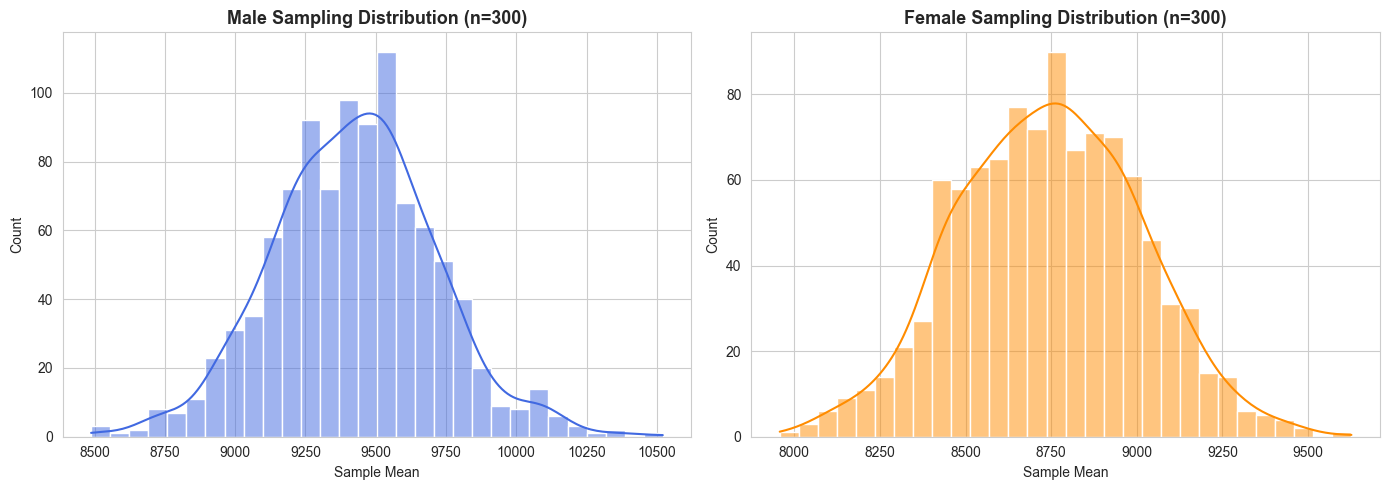


***************************************************************************
CLT ANALYSIS FOR SAMPLE SIZE = 3000
***************************************************************************

Male CI : (np.float64(9257.987550058653), np.float64(9597.64433927468))
Female CI : (np.float64(8567.82562555036), np.float64(8904.632629782975))

Male CI Width : 339.66
Female CI Width : 336.81

Confidence Intervals DO NOT overlap

Interpretation:
Average spending differs significantly between 
Male and Female. 


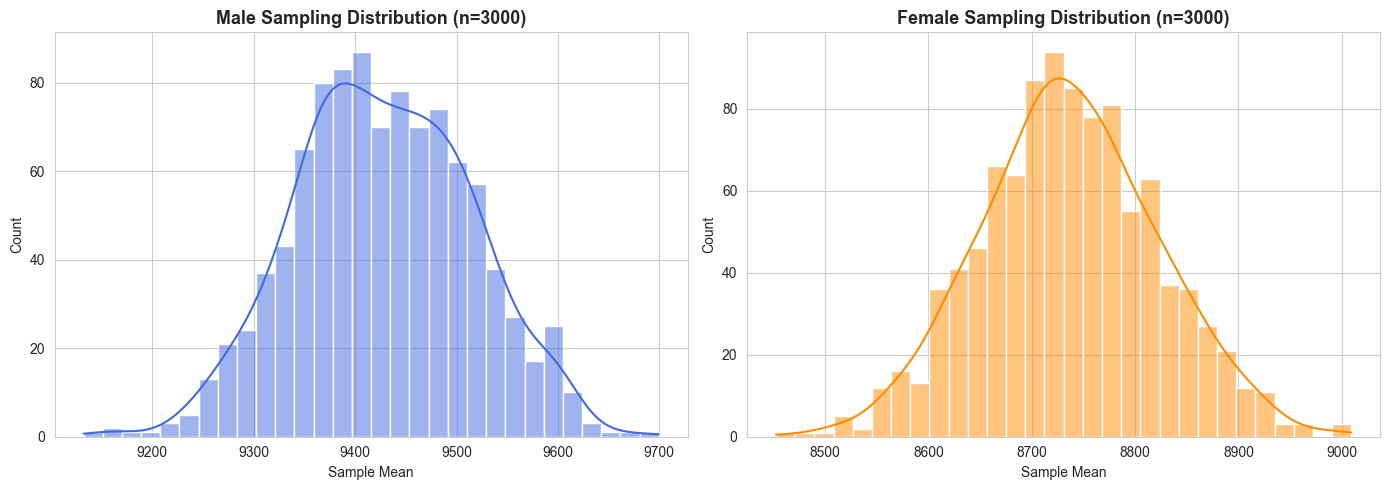


***************************************************************************
CLT ANALYSIS FOR SAMPLE SIZE = 30000
***************************************************************************

Male CI : (np.float64(9370.990970472456), np.float64(9482.119390594213))
Female CI : (np.float64(8685.874502942714), np.float64(8789.135701590616))

Male CI Width : 111.13
Female CI Width : 103.26

Confidence Intervals DO NOT overlap

Interpretation:
Average spending differs significantly between 
Male and Female. 


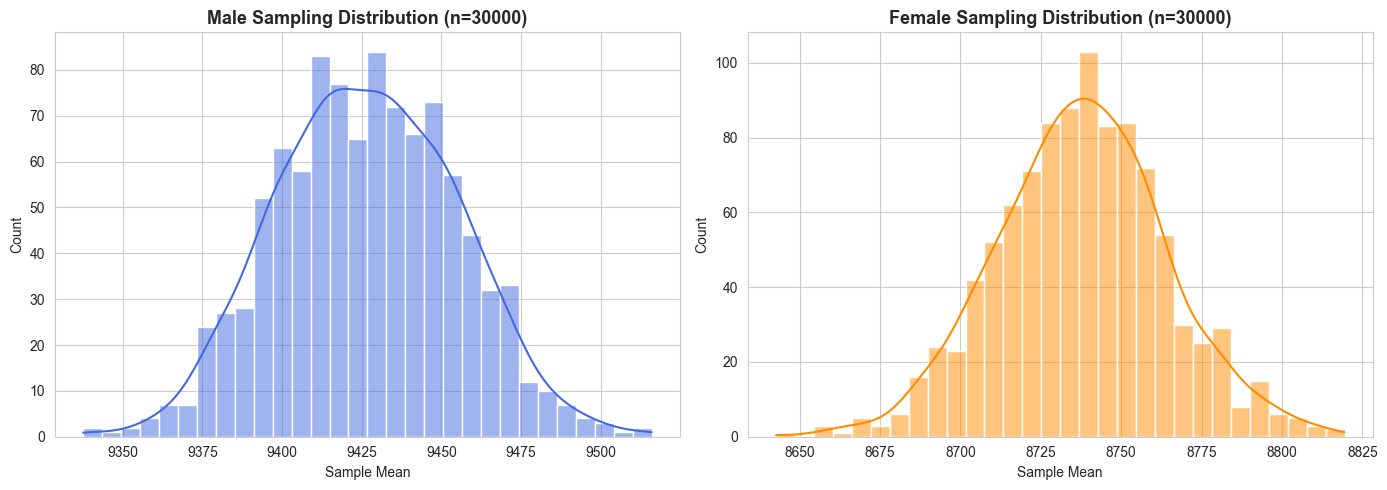


***************************************************************************
FINAL RESULTS TABLE
***************************************************************************
   Sample_Size  Male_CI_Lower  Male_CI_Upper  Male_CI_Width  Female_CI_Lower  \
0          300    8855.164195    9991.138865    1135.974671      8219.953489   
1         3000    9257.987550    9597.644339     339.656789      8567.825626   
2        30000    9370.990970    9482.119391     111.128420      8685.874503   

   Female_CI_Upper  Female_CI_Width  
0      9264.509544      1044.556056  
1      8904.632630       336.807004  
2      8789.135702       103.261199  


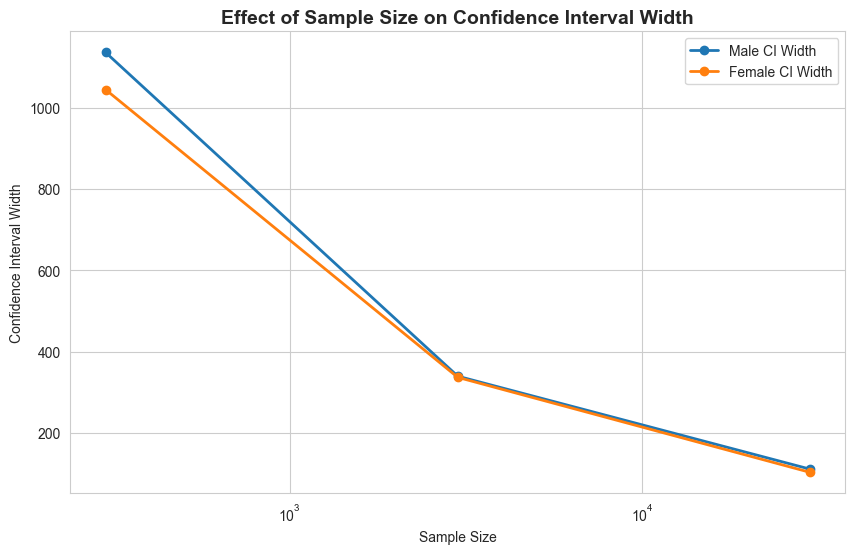

In [148]:
male_purchase = df[df['Gender'] == 'M']['Purchase']

female_purchase = df[df['Gender'] == 'F']['Purchase']

gender_results = clt_analysis(
    male_purchase,
    female_purchase,
    group1_name='Male',
    group2_name='Female'
)

* Male customers consistently show higher average purchase amounts compared to female customers across all sampling scenarios.

* The confidence intervals computed using the full dataset are very narrow because the dataset contains a very large number of observations, reducing sampling variability and uncertainty.

* For smaller sample sizes (n = 300), the confidence intervals are much wider and overlap with each other, indicating higher uncertainty in estimating the true population mean.

* As the sample size increases from 300 → 3000 → 30000, the width of the confidence intervals decreases significantly, showing that larger samples produce more stable and reliable estimates.

* Confidence intervals for sample sizes 3000 and 30000 do not overlap between genders, suggesting a statistically significant difference in spending behavior between male and female customers.

* The sampling distributions become increasingly normal and concentrated around the mean as sample size increases, validating the Central Limit Theorem (CLT).

* Larger sample sizes reduce standard error and variability, making the estimated mean purchase values more accurate and statistically reliable.


###### Marital_Status vs Purchase


***************************************************************************
CLT & CONFIDENCE INTERVAL ANALYSIS
Married vs Unmarried
***************************************************************************

FULL DATASET CONFIDENCE INTERVALS
---------------------------------------------------------------------------

Married Mean : 9253.67
Married CI   : (np.float64(9233.671668620094), np.float64(9273.667978219974))

Unmarried Mean : 9258.82
Unmarried CI   : (np.float64(9242.089086233358), np.float64(9275.551841180408))

OVERLAP INTERPRETATION
---------------------------------------------------------------------------

Confidence Intervals overlap

Interpretation:
Average spending behavior may be similar between
Married and Unmarried.

***************************************************************************
CLT ANALYSIS FOR SAMPLE SIZE = 300
***************************************************************************

Married CI : (np.float64(8700.566494401783), np.float64(9751.138

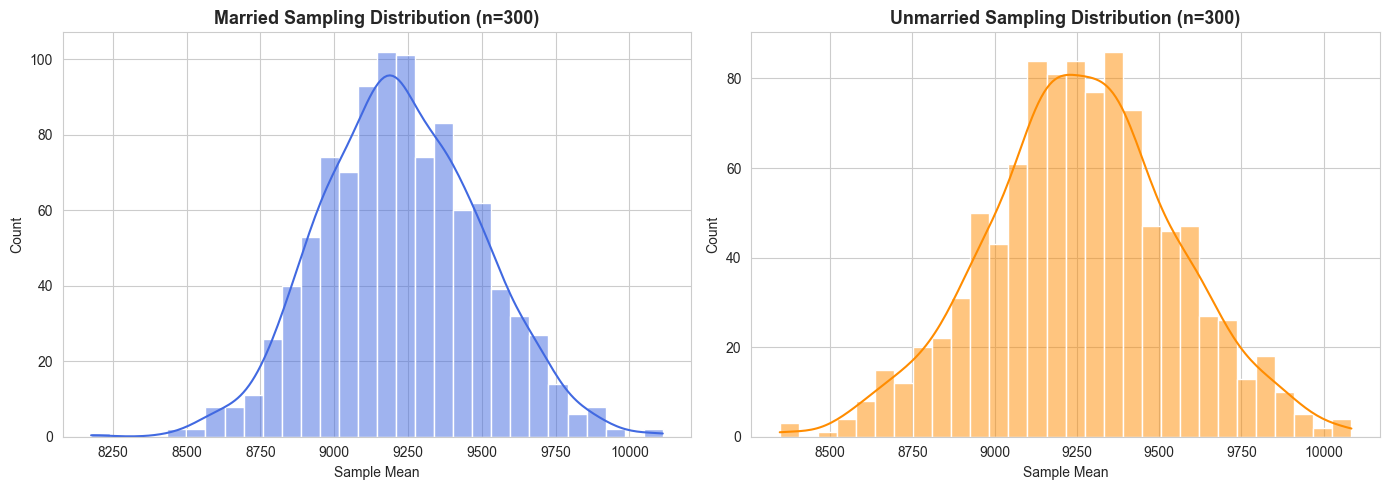


***************************************************************************
CLT ANALYSIS FOR SAMPLE SIZE = 3000
***************************************************************************

Married CI : (np.float64(9082.4381090741), np.float64(9429.263679592565))
Unmarried CI : (np.float64(9079.416040888987), np.float64(9434.903016444347))

Married CI Width : 346.83
Unmarried CI Width : 355.49

Confidence Intervals overlap

Interpretation:
Average spending behavior may be similar between
Married and Unmarried.


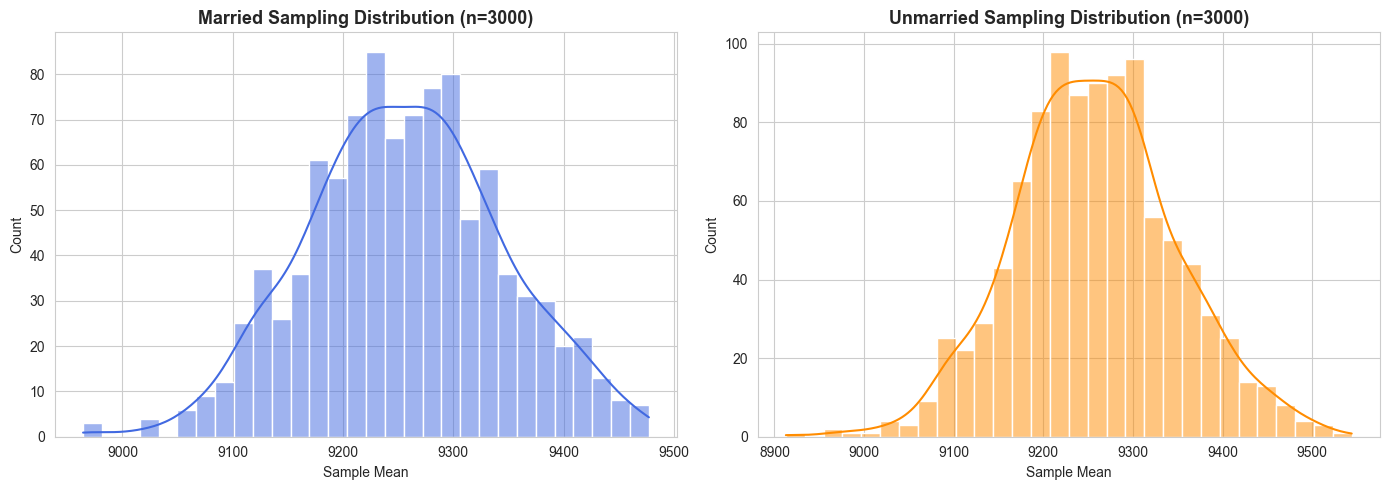


***************************************************************************
CLT ANALYSIS FOR SAMPLE SIZE = 30000
***************************************************************************

Married CI : (np.float64(9202.453728336874), np.float64(9307.510112729793))
Unmarried CI : (np.float64(9204.792407432677), np.float64(9312.907797833988))

Married CI Width : 105.06
Unmarried CI Width : 108.12

Confidence Intervals overlap

Interpretation:
Average spending behavior may be similar between
Married and Unmarried.


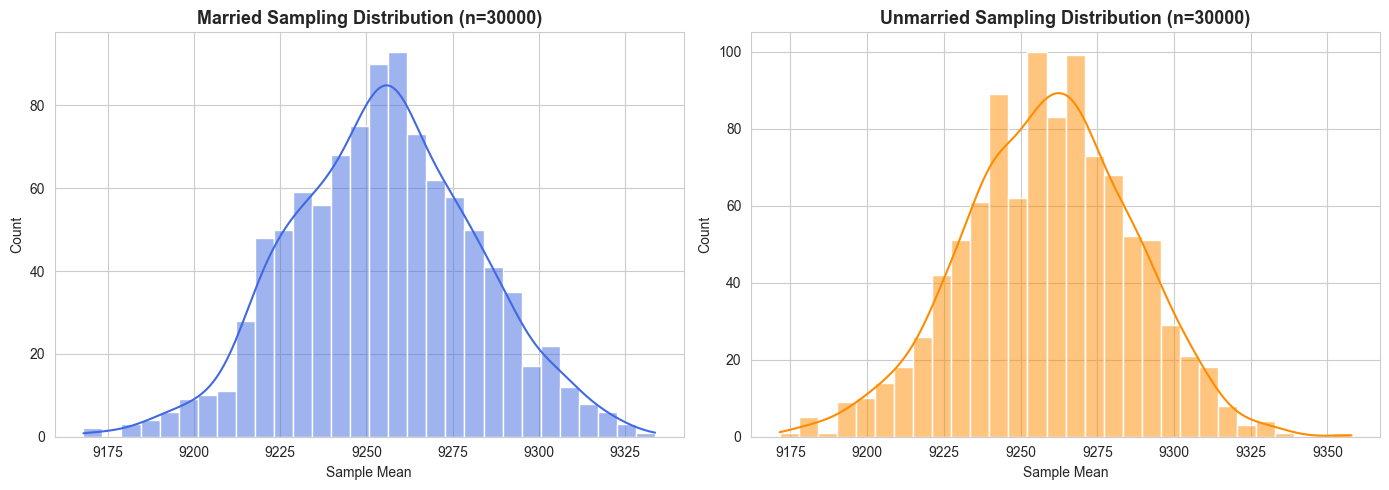


***************************************************************************
FINAL RESULTS TABLE
***************************************************************************
   Sample_Size  Married_CI_Lower  Married_CI_Upper  Married_CI_Width  \
0          300       8700.566494       9751.138019       1050.571525   
1         3000       9082.438109       9429.263680        346.825571   
2        30000       9202.453728       9307.510113        105.056384   

   Unmarried_CI_Lower  Unmarried_CI_Upper  Unmarried_CI_Width  
0         8696.253260         9827.032973         1130.779712  
1         9079.416041         9434.903016          355.486976  
2         9204.792407         9312.907798          108.115390  


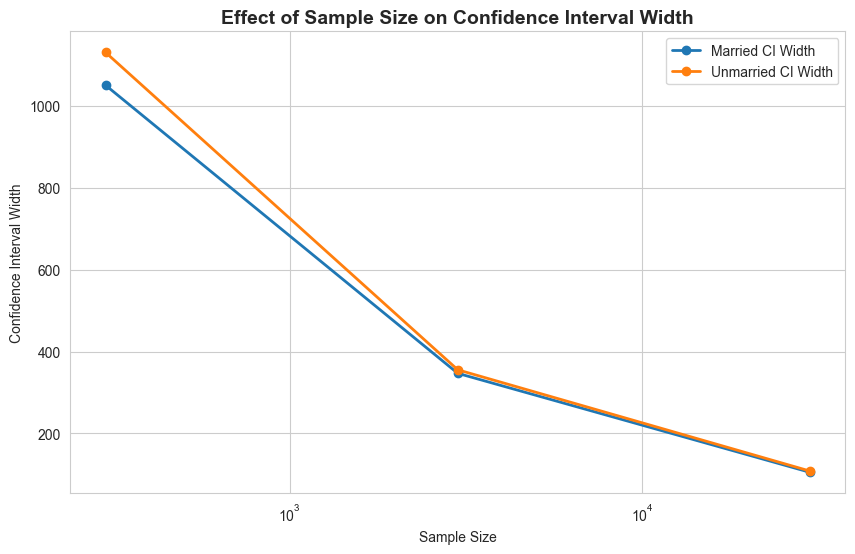

In [149]:
married_purchase = df[df['Marital_Status'] == 1]['Purchase']

unmarried_purchase = df[df['Marital_Status'] == 0]['Purchase']

marital_results = clt_analysis(
    married_purchase,
    unmarried_purchase,
    group1_name='Married',
    group2_name='Unmarried'
)

* Married and unmarried customers show almost identical average purchase behavior across all sample sizes.

* The confidence intervals computed using the full dataset are narrow and highly overlapping, indicating very little difference in spending patterns between married and unmarried customers.

* For smaller sample sizes (n = 300), the confidence intervals become much wider due to higher sampling variability and uncertainty.

* As the sample size increases from 300 → 3000 → 30000, the confidence interval widths decrease significantly, showing that larger sample sizes produce more stable and reliable estimates.

* The confidence intervals overlap for all sample sizes, suggesting that marital status does not have a strong influence on customer spending behavior.

* The sampling distributions become more normally distributed and concentrated around the mean as sample size increases, validating the Central Limit Theorem (CLT).

* Increasing sample size reduces standard error and variability, leading to more accurate estimation of the population mean purchase amount.


###### Age vs Purchase


***************************************************************************
CLT & CONFIDENCE INTERVAL ANALYSIS
18-25 vs 26-35
***************************************************************************

FULL DATASET CONFIDENCE INTERVALS
---------------------------------------------------------------------------

18-25 Mean : 9169.01
18-25 CI   : (np.float64(9138.654879528036), np.float64(9199.36707511776))

26-35 Mean : 9243.78
26-35 CI   : (np.float64(9223.47286546184), np.float64(9264.087372621472))

OVERLAP INTERPRETATION
---------------------------------------------------------------------------

Confidence Intervals DO NOT overlap

Interpretation:
Average spending differs significantly between 
18-25 and 26-35. 

***************************************************************************
CLT ANALYSIS FOR SAMPLE SIZE = 300
***************************************************************************

18-25 CI : (np.float64(8618.446009405241), np.float64(9693.191197261422))
26-35 CI 

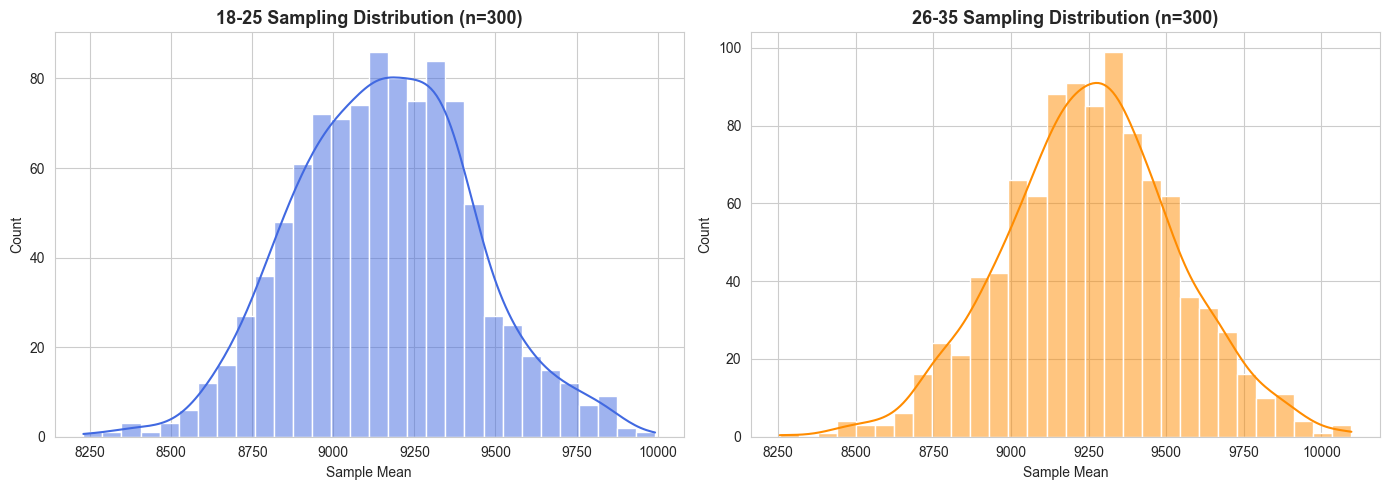


***************************************************************************
CLT ANALYSIS FOR SAMPLE SIZE = 3000
***************************************************************************

18-25 CI : (np.float64(8994.436628971964), np.float64(9332.605405028038))
26-35 CI : (np.float64(9070.064530210448), np.float64(9418.412623789553))

18-25 CI Width : 338.17
26-35 CI Width : 348.35

Confidence Intervals overlap

Interpretation:
Average spending behavior may be similar between
18-25 and 26-35.


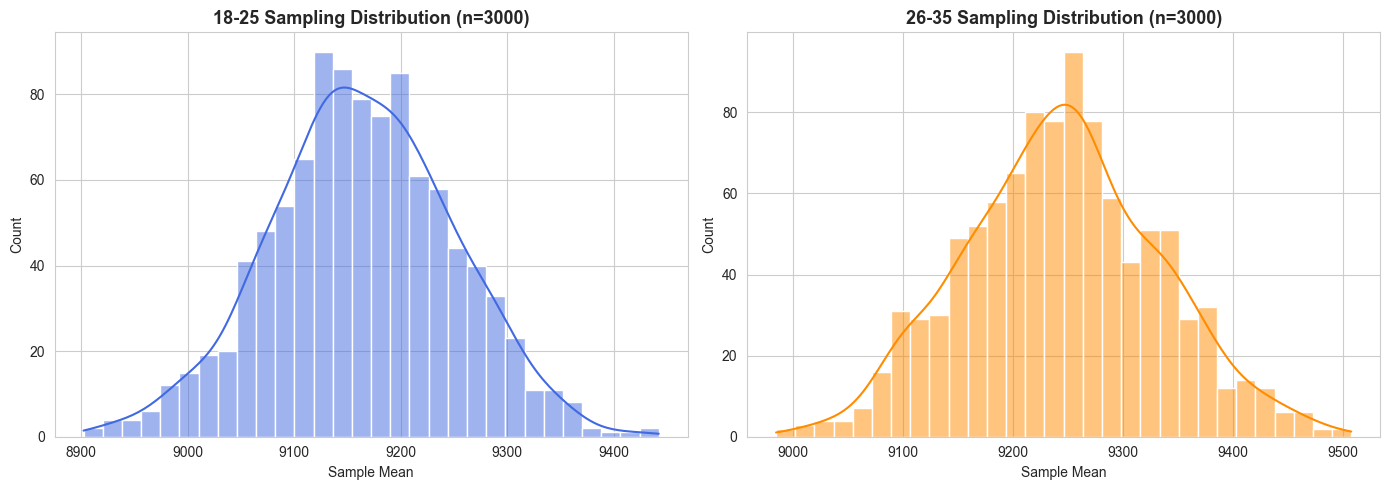


***************************************************************************
CLT ANALYSIS FOR SAMPLE SIZE = 30000
***************************************************************************

18-25 CI : (np.float64(9113.418978645435), np.float64(9226.353068154565))
26-35 CI : (np.float64(9186.99767223001), np.float64(9301.506313969987))

18-25 CI Width : 112.93
26-35 CI Width : 114.51

Confidence Intervals overlap

Interpretation:
Average spending behavior may be similar between
18-25 and 26-35.


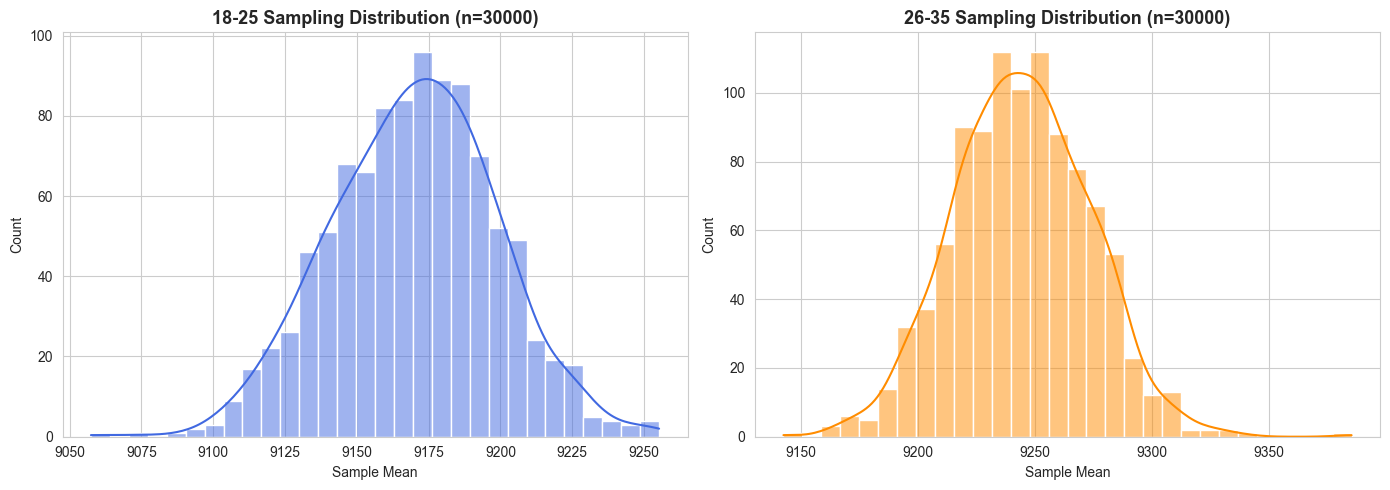


***************************************************************************
FINAL RESULTS TABLE
***************************************************************************
   Sample_Size  18-25_CI_Lower  18-25_CI_Upper  18-25_CI_Width  \
0          300     8618.446009     9693.191197     1074.745188   
1         3000     8994.436629     9332.605405      338.168776   
2        30000     9113.418979     9226.353068      112.934090   

   26-35_CI_Lower  26-35_CI_Upper  26-35_CI_Width  
0     8712.087014     9800.671826     1088.584811  
1     9070.064530     9418.412624      348.348094  
2     9186.997672     9301.506314      114.508642  


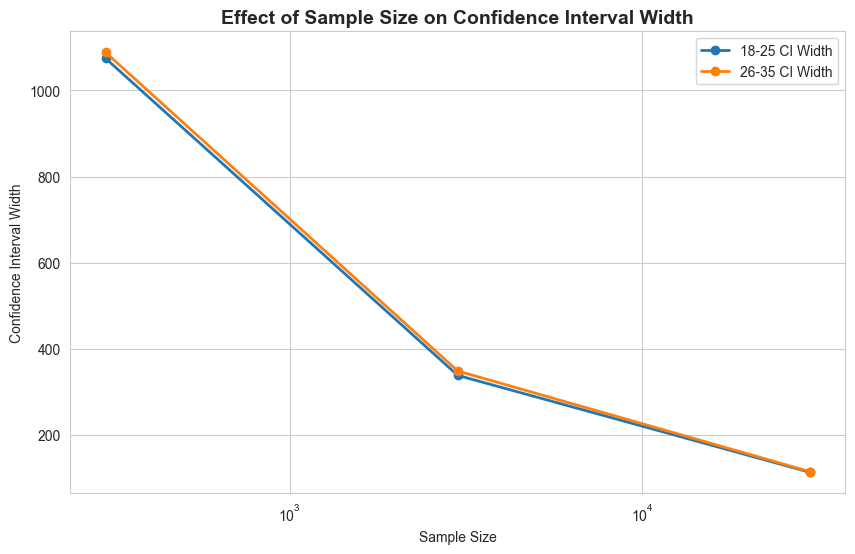

In [150]:
age1 = df[df['Age'] == '18-25']['Purchase']

age2 = df[df['Age'] == '26-35']['Purchase']

age_results = clt_analysis(
    age1,
    age2,
    group1_name='18-25',
    group2_name='26-35'
)

* Customers in the 26–35 age group exhibit slightly higher average purchase amounts compared to customers in the 18–25 age group.

* The confidence intervals computed using the full dataset are narrow and do not overlap, indicating a statistically significant difference in average spending behavior between the two age groups.

* For smaller sample sizes (n = 300), the confidence intervals are much wider and overlap considerably, showing higher uncertainty and variability in the estimates.

* As the sample size increases from 300 → 3000 → 30000, the confidence interval widths decrease substantially, resulting in more stable and reliable estimates of the population mean.

* Confidence intervals overlap for the sampled datasets despite the full dataset showing separation, suggesting that the difference between the two age groups is relatively moderate rather than extremely strong.

* The sampling distributions become increasingly normal and concentrated around the mean as sample size increases, supporting the Central Limit Theorem (CLT).

* Larger sample sizes reduce standard error and sampling variability, improving the accuracy and consistency of estimated mean purchase behavior.


#### Final CLT-Based Business Report


##### a. Gender vs Purchase Analysis

The confidence intervals for male and female customers computed using the full dataset do not overlap, indicating a statistically significant difference in average spending behavior between genders. Male customers exhibit higher average purchase amounts compared to female customers.

###### Business Implications

* Walmart can target high-spending male customers using premium product recommendations and personalized marketing campaigns.
* Female customers represent a potential growth opportunity, where targeted offers and category-specific promotions may help improve engagement and spending.
* Gender-based customer segmentation can improve recommendation systems and marketing efficiency.

---

##### b. Marital Status vs Purchase Analysis

The confidence intervals for married and unmarried customers overlap significantly, suggesting that marital status does not strongly influence customer spending behavior.

###### Business Implications

* Marital status alone may not be an effective feature for customer targeting or segmentation.
* Walmart should prioritize stronger behavioral and demographic variables such as product category, city category, and gender instead of marital status.
* Resources spent on marital-status-specific campaigns may provide limited business impact.

---

##### c. Age Group vs Purchase Analysis

The confidence intervals for the 18–25 and 26–35 age groups computed using the full dataset do not overlap, indicating a measurable difference in spending behavior between the two age groups. Customers in the 26–35 age group exhibit slightly higher average purchase amounts.

###### Business Implications

* Customers aged 26–35 represent a strong purchasing segment and can be prioritized for premium product promotions and loyalty programs.
* Younger customers (18–25) may respond better to discounts, bundled offers, and price-sensitive marketing strategies.
* Age-based personalization can help Walmart improve customer retention and targeted advertising performance.


### Final Business Recommendations & Strategic Insights Report



#### 1. Executive Summary

The analysis of Walmart customer purchase behavior reveals that customer spending patterns are primarily influenced by:

* Product Category
* Gender
* City Category
* Age Group

while variables such as:

* Marital Status
* Stay in Current City Years

show relatively limited practical influence on spending behavior.

The study combined:

* Univariate Analysis
* Bivariate Analysis
* Multivariate Analysis
* Statistical Testing
* Central Limit Theorem (CLT)
* Confidence Interval Analysis

to identify significant customer purchasing patterns and generate actionable business recommendations.

---

#### 2. Key Business Insights

##### 2.1 Product Category is the Strongest Purchase Driver

Product categories exhibit the largest variation in purchase amount compared to demographic variables.

##### Key Findings

* Product Categories 9, 10, 15, and 16 consistently show the highest purchase values.
* Categories 12, 13, 19, and 20 show minimal variance, suggesting relatively fixed-price products.
* Product preference influences purchase amount more strongly than gender or marital status.

##### Business Impact

* Product category should become the primary driver for:

  * recommendation systems
  * inventory optimization
  * customer targeting strategies
  * personalized promotions

---

#### 2.2 Male Customers Represent the Largest Revenue-Contributing Segment

The dataset shows:

* Male customers form the majority of the customer base.
* Male customers consistently exhibit higher average purchase amounts.
* Confidence interval analysis confirms statistically significant differences in spending between male and female customers.

##### Hidden Relationship Identified

The gender effect becomes stronger in:

* premium product categories
* high-spending city segments

particularly within City Category C.

##### Business Impact

* Premium product campaigns can be targeted more aggressively toward high-value male customer segments.
* Walmart should simultaneously develop strategies to improve premium conversion among female customers.

---

#### 2.3 Female Customers Represent an Untapped Growth Opportunity

Although female customers currently spend less on average:

* they still represent a significant customer segment.
* several product categories show relatively balanced purchasing behavior.

##### Business Opportunity

This suggests:

* female customers are underpenetrated rather than inactive.
* improved personalization and category-specific targeting may increase female customer spending.

##### Recommendations

* Introduce female-focused recommendation systems.
* Improve visibility of premium product categories among female customers.
* Create category-based promotional campaigns targeting female shoppers.

---

#### 2.4 City Category C Contains High-Value Customers

Customers from City Category C consistently exhibit:

* highest average purchase behavior
* strongest premium spending concentration

##### Hidden Relationship Identified

The spending gap between male and female customers becomes largest within City Category C.

This suggests:

* stronger purchasing power
* higher-value customer concentration
* increased premium purchase tendency

within this region.

##### Business Impact

* City Category C should receive:

  * premium inventory priority
  * high-margin product campaigns
  * loyalty-focused marketing
  * personalized recommendation strategies

---

#### 2.5 Medium Spend Customers Form Walmart’s Core Customer Base

Across nearly all demographic groups:

* Medium Spend customers dominate customer distribution.

##### Business Interpretation

Walmart’s business is strongly supported by:

* stable moderate spenders
* recurring value-oriented shoppers

rather than exclusively premium customers.

### Recommendations

* Focus retention strategies on medium-spend customers.
* Build upselling funnels to gradually convert medium spenders into premium customers.

---

## 2.6 Age Group 26–35 Represents the Most Valuable Active Segment

The 26–35 age group:

* forms the largest customer segment
* shows relatively higher average spending behavior

compared to younger age groups.

### Hidden Relationship Identified

Although statistical significance exists between age groups, the practical difference remains moderate due to overlapping spending distributions.

### Business Impact

* Customers aged 26–35 should become a priority demographic for:

  * loyalty programs
  * premium promotions
  * targeted recommendations
  * personalized advertising

---

## 2.7 Marital Status Has Limited Predictive Importance

Confidence intervals for married and unmarried customers overlap significantly across all sample sizes.

### Business Interpretation

Marital status does not strongly influence spending behavior.

### Recommendation

* Marital status should not be treated as a primary segmentation variable.
* Walmart should focus more heavily on:

  * product preference
  * purchase history
  * city category
  * customer spending behavior

instead of marital-status-based targeting.

---

# 3. Statistical & CLT Insights

The Central Limit Theorem and bootstrapping analysis demonstrated that:

* Larger sample sizes produce:

  * narrower confidence intervals
  * lower variability
  * more stable estimates
  * approximately normal sampling distributions

### Important Business Insight

Small sample sizes may produce misleading conclusions due to higher uncertainty.

This highlights the importance of:

* large-scale customer data analysis
* statistically reliable sampling
* data-driven business decisions

before launching large marketing or pricing strategies.

---

# 4. Strategic Business Recommendations

## 4.1 Build Personalized Recommendation Systems

### Why

Purchase behavior strongly depends on:

* product category
* gender
* city category
* spending history

### Recommended Actions

Develop recommendation systems using:

* purchase history
* product affinity
* customer demographics
* spending behavior

### Expected Outcome

* Increased basket size
* Improved customer retention
* Higher premium conversion

---

## 4.2 Expand Premium Customer Segments

### Target Segments

* Male premium customers
* City Category C customers
* High-value product-category shoppers
* 26–35 age group customers

### Recommended Actions

* Premium loyalty programs
* Personalized premium recommendations
* Exclusive product launches
* High-value customer rewards

---

## 4.3 Improve Female Customer Conversion

### Problem

Female customers show lower average purchase behavior despite representing a large customer segment.

### Recommendations

* Personalized product discovery
* Category-specific campaigns
* Premium accessibility promotions
* Female-focused product bundling

### Expected Outcome

* Increased female customer engagement
* Higher average basket value
* Expanded premium customer base

---

## 4.4 Optimize Inventory Regionally

### Observation

Different city categories exhibit different spending patterns.

### Recommended Actions

* Allocate premium inventory more aggressively in City Category C.
* Focus discount/value-oriented inventory in City Category A.
* Use regional demand forecasting for inventory planning.

---

## 4.5 Develop Customer Segmentation Pipelines

### Suggested Segments

| Segment                | Characteristics                   |
| ---------------------- | --------------------------------- |
| Low Spend Customers    | Price-sensitive, discount-driven  |
| Medium Spend Customers | Stable recurring customers        |
| Premium Customers      | High-margin, high-value customers |

### Business Goal

Enable:

* dynamic targeting
* personalized campaigns
* customer retention strategies
* premium upselling

---

# 5. Future Scope & Advanced Extensions

The current analysis can be extended into a full-scale machine learning system capable of:

* Purchase prediction
* Customer segmentation
* Recommendation systems
* Targeted advertisement generation
* Customer lifetime value prediction

Potential deployment through:

* Streamlit
* Flask
* FastAPI

can allow real-time customer behavior prediction and personalized marketing applications.

---

# 6. Final Conclusion

The analysis demonstrates that Walmart customer purchase behavior is primarily driven by:

* Product Category
* Gender
* City Category
* Age Group

while marital status and residency duration contribute relatively little practical influence.

The combination of:

* EDA
* statistical testing
* confidence interval analysis
* CLT validation

provided statistically reliable and business-relevant insights into customer behavior.

The findings can help Walmart:

* optimize marketing strategies
* improve customer targeting
* enhance recommendation systems
* increase premium customer conversion
* improve inventory allocation
* make data-driven business decisions

ultimately improving customer engagement, operational efficiency, and revenue growth.
